In [1]:
import pandas as pd # import de la librairie pandas pour visualier et travailler les dataframes
import numpy as np #import de numpy pour les calculs simples
import matplotlib.pyplot as plt #import de matplotlib pour visualiser graphiques, courbes
import seaborn as sns #import de seaborn pour graphiques
import scipy.stats as st #import de scipy pour les statistiques et statistiques descriptives
import shap

C:\Users\chris\AppData\Local\pypoetry\Cache\virtualenvs\classification-auto-des-informations-Cx0GgdV--py3.13\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,StratifiedKFold,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, roc_curve, auc, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder, RobustScaler

#Modèles
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from shap import TreeExplainer


In [3]:
extrait_eval=pd.read_csv('extrait_eval.csv') 

In [4]:
extrait_sirh=pd.read_csv('extrait_sirh.csv') 

In [5]:
extrait_sondage=pd.read_csv('extrait_sondage.csv') 

In [6]:
extrait_eval.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [7]:
extrait_sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [8]:
extrait_sondage.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [9]:
extrait_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   satisfaction_employee_environnement        1470 non-null   int64 
 1   note_evaluation_precedente                 1470 non-null   int64 
 2   niveau_hierarchique_poste                  1470 non-null   int64 
 3   satisfaction_employee_nature_travail       1470 non-null   int64 
 4   satisfaction_employee_equipe               1470 non-null   int64 
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64 
 6   eval_number                                1470 non-null   object
 7   note_evaluation_actuelle                   1470 non-null   int64 
 8   heure_supplementaires                      1470 non-null   object
 9   augementation_salaire_precedente           1470 non-null   object
dtypes: int64(7), object(3)
memory usage:

In [10]:
#visualisation des valeurs manquantes(pas de valeurs manquantes car on a 1470 échantillons pour 1470 non-null counts)
extrait_eval.isnull().sum();

In [11]:
# recherche des doublons: False sur l'ensemble du dataframe =>pas de doublons
extrait_eval.duplicated().value_counts()

False    1470
Name: count, dtype: int64

In [12]:
# verification des valeurs prises par la colonne
extrait_eval['satisfaction_employee_environnement'].describe();

In [13]:
extrait_eval['note_evaluation_precedente'].describe();

In [14]:
extrait_eval['niveau_hierarchique_poste'].describe();

In [15]:
extrait_eval['satisfaction_employee_nature_travail'].describe();

In [16]:
extrait_eval['satisfaction_employee_equipe'].describe();

In [17]:
extrait_eval['satisfaction_employee_equilibre_pro_perso'].describe();

In [18]:
# eval_number, id_employe et code_sondage semblent être la clé pour fusionner extrait_val, extrait_sirh et extrait_sondage
extrait_eval['eval_number'].value_counts()

eval_number
E_1       1
E_2       1
E_4       1
E_5       1
E_7       1
         ..
E_2061    1
E_2062    1
E_2064    1
E_2065    1
E_2068    1
Name: count, Length: 1470, dtype: int64

In [19]:
extrait_eval['note_evaluation_actuelle'].describe();

In [20]:
extrait_eval['heure_supplementaires'].describe();

In [21]:
extrait_eval['augementation_salaire_precedente'].describe();

In [22]:
extrait_sirh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


In [23]:
#visualisation des valeurs manquantes(a priori pas de valeurs manquantes car on a 1470 échantillons pour 1470 non-null counts)
extrait_sirh.isnull().sum();

In [24]:
# recherche des doublons: False sur l'ensemble du dataframe=>pas de doublons
extrait_sirh.duplicated().value_counts()

False    1470
Name: count, dtype: int64

In [25]:
# eval_number, id_employe et code_sondage semblent être la clé pour fusionner extrait_val, extrait_sirh et extrait_sondage
extrait_sirh['id_employee'].value_counts

<bound method IndexOpsMixin.value_counts of 0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: id_employee, Length: 1470, dtype: int64>

In [26]:
# les valeurs de la variable age sont conformes
extrait_sirh['age'].value_counts();

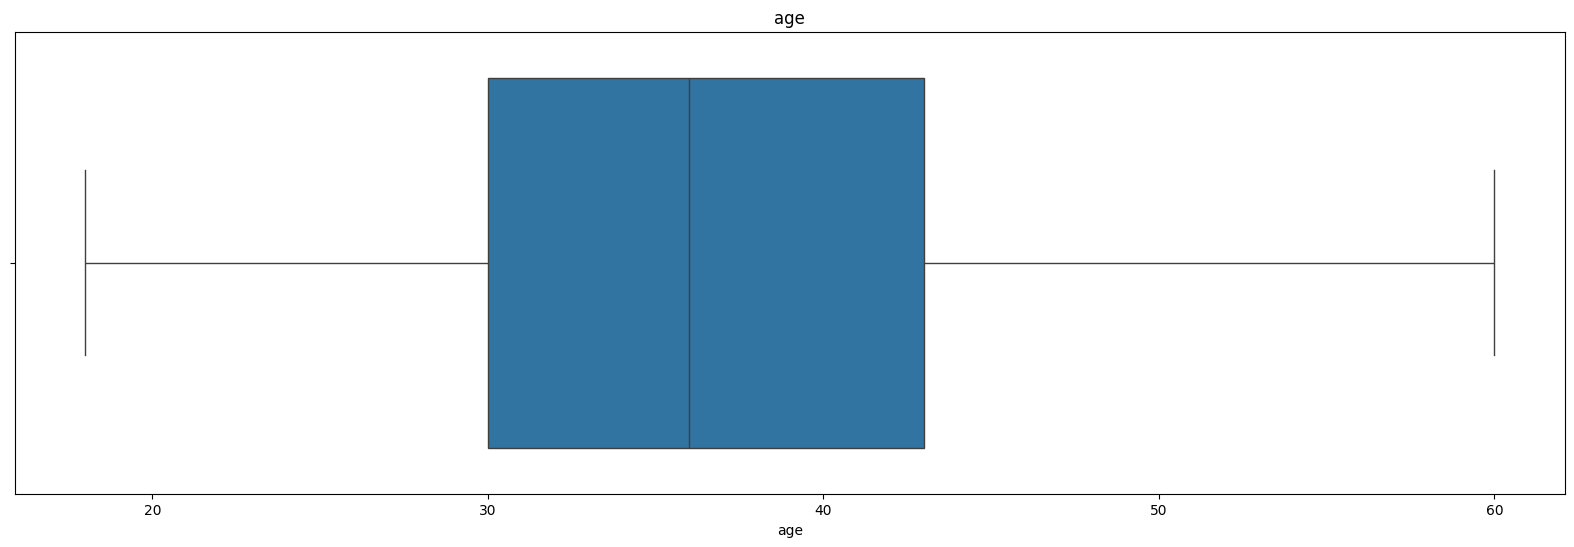

In [27]:
#valeur de la variable age (en boxplot); la mediane 
plt.figure(figsize=(20, 6))
sns.boxplot(data=extrait_sirh, x='age')
plt.title('age')
plt.show()

In [28]:
extrait_sirh['genre'].value_counts();

In [29]:
extrait_sirh['revenu_mensuel'].describe();

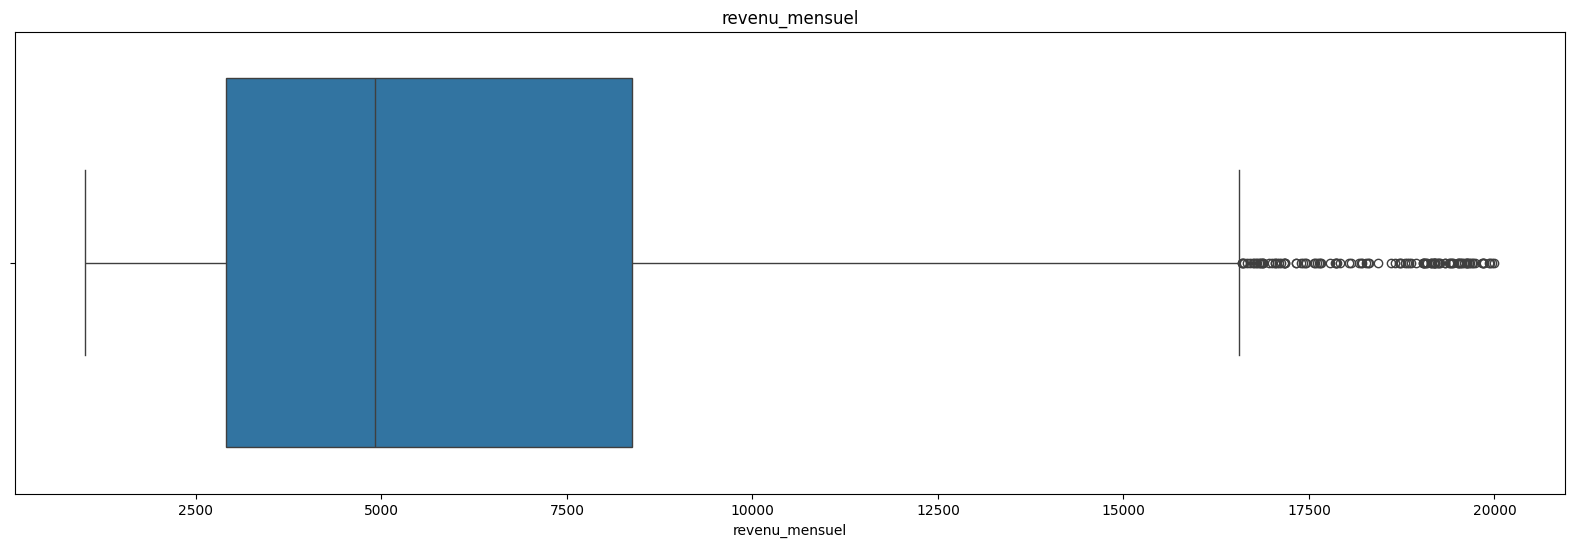

In [30]:
#valeur de la variable revenu mensuel (en boxplot)
plt.figure(figsize=(20, 6))
sns.boxplot(data=extrait_sirh, x='revenu_mensuel')
plt.title('revenu_mensuel')
plt.show()

In [31]:
# on voit bien sur la boxplot que la moyenne est supérieure à la médiane en raison des salaires élevés ; les valeurs sont plausibles


In [32]:
extrait_sirh['statut_marital'].describe();

In [33]:
extrait_sirh['departement'].describe();

In [34]:
extrait_sirh['poste'].describe();

In [35]:
extrait_sirh['annee_experience_totale'].unique()

array([ 8, 10,  7,  6, 12,  1, 17,  5,  3, 31, 13,  0, 26, 24, 22,  9, 19,
        2, 23, 14, 15,  4, 29, 28, 21, 25, 20, 11, 16, 37, 38, 30, 40, 18,
       36, 34, 32, 33, 35, 27])

In [36]:
extrait_sirh['nombre_experiences_precedentes'].describe();

In [37]:
extrait_sirh['nombre_heures_travailless'].value_counts()

nombre_heures_travailless
80    1470
Name: count, dtype: int64

In [38]:
# une seule valeur de nombre d'heures travaillées => la colonne ne sert à rien dans l'analyse du modèle de prédiction
extrait_sirh.drop(columns=['nombre_heures_travailless'], inplace=True)

In [39]:
extrait_sirh['annees_dans_l_entreprise'].describe();

In [40]:
extrait_sirh['annees_dans_le_poste_actuel'].describe();

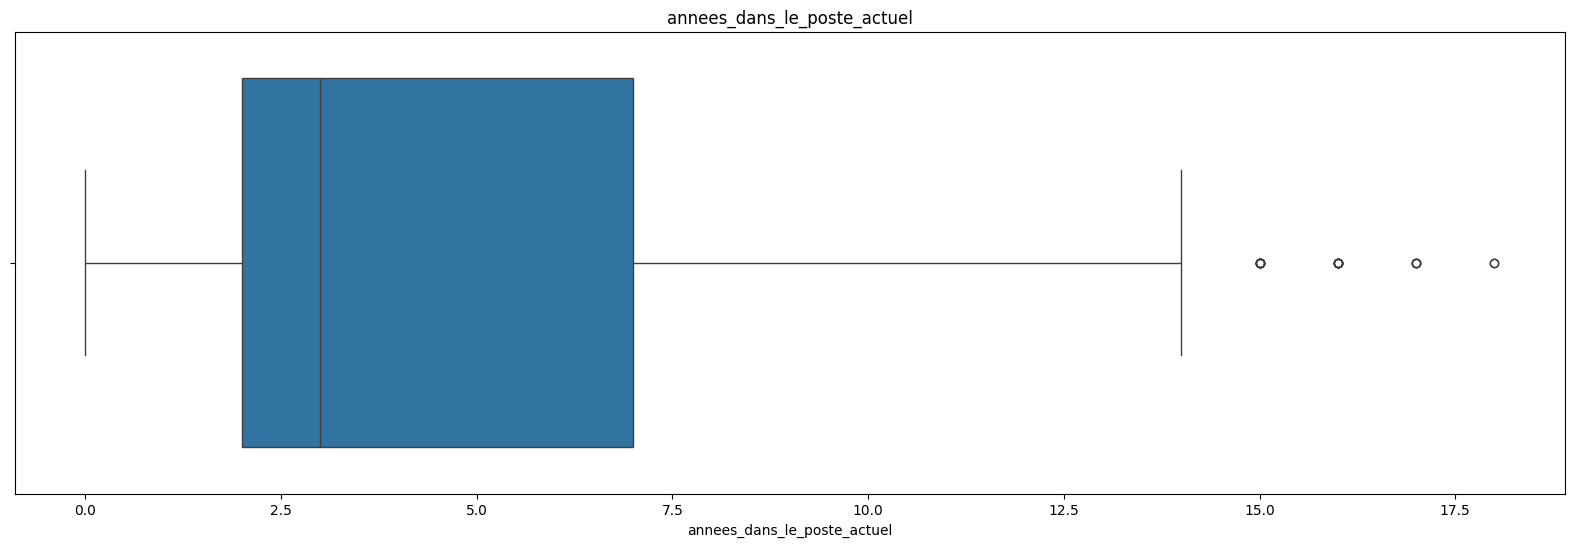

In [41]:
# rien de bien inquiétant, les valeurs fortes ne sont pas considérées comme des outliers
plt.figure(figsize=(20, 6))
sns.boxplot(data=extrait_sirh, x='annees_dans_le_poste_actuel')
plt.title('annees_dans_le_poste_actuel')
plt.show()

In [42]:
extrait_sondage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   object
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

In [43]:
#visualisation des valeurs manquantes(a priori pas de valeurs manquantes car on a 1470 échantillons pour 1470 non-null counts)
extrait_sondage.isnull().sum();

In [44]:
# recherche des doublons: False sur l'ensemble du dataframe=>pas de doublons
extrait_sondage.duplicated().value_counts()

False    1470
Name: count, dtype: int64

In [45]:
# a_quitte_l_entreprise est notre variable y à prédire
extrait_sondage['a_quitte_l_entreprise'].value_counts;

In [46]:
extrait_sondage.loc[extrait_sondage['a_quitte_l_entreprise']=="Oui"].value_counts;

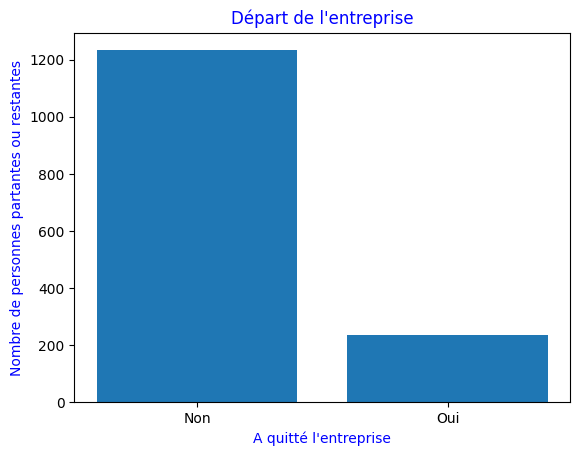

In [47]:
comptage = extrait_sondage['a_quitte_l_entreprise'].value_counts()

# Diagramme en barres
plt.bar(comptage.index, comptage.values)
plt.xlabel('A quitté l\'entreprise', color='blue')
plt.ylabel('Nombre de personnes partantes ou restantes',color='blue')
plt.title('Départ de l\'entreprise',color='blue')
plt.show()

In [48]:
extrait_sondage['nombre_participation_pee'].describe();

In [49]:
extrait_sondage['nb_formations_suivies'].describe();

In [50]:
extrait_sondage['nombre_employee_sous_responsabilite'].value_counts()

nombre_employee_sous_responsabilite
1    1470
Name: count, dtype: int64

In [51]:
# une seule valeur de nombre employee sous responsabilité => la colonne ne sert à rien dans l'analyse du modèle de prédiction
extrait_sondage.drop(columns=['nombre_employee_sous_responsabilite'], inplace=True)

In [52]:
# eval_number, id_employe et code_sondage semblent être la clé pour fusionner extrait_val, extrait_sirh et extrait_sondage

In [53]:
extrait_sondage['code_sondage'].describe();

In [54]:
extrait_sondage['distance_domicile_travail'].value_counts();

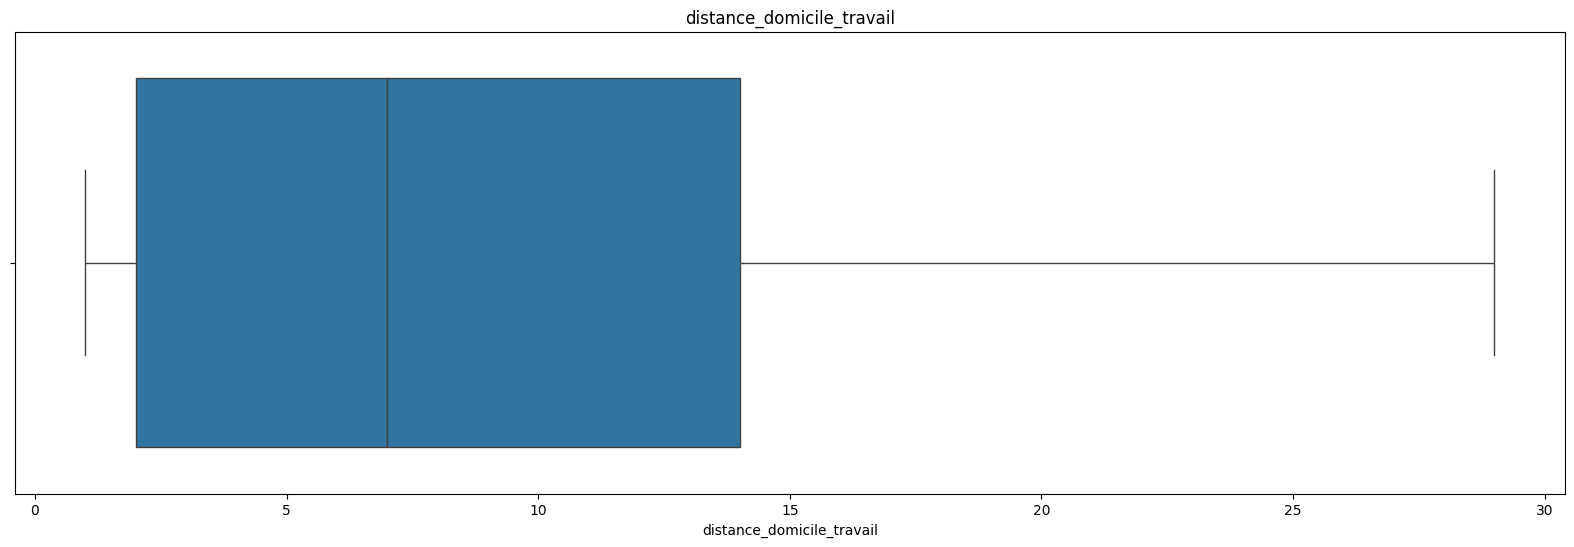

In [55]:
plt.figure(figsize=(20, 6))
sns.boxplot(data=extrait_sondage, x='distance_domicile_travail')
plt.title('distance_domicile_travail')
plt.show()

In [56]:
extrait_sondage['niveau_education'].value_counts();

In [57]:
extrait_sondage['domaine_etude'].value_counts();

In [58]:
extrait_sondage['ayant_enfants'].value_counts();

In [59]:
#nombre de Y dans la colonne ayant des enfants
extrait_sondage['ayant_enfants'].value_counts().get('Y', 0)

np.int64(1470)

In [60]:
# une seule valeur de ayant des enfants=> la colonne ne sert à rien dans l'analyse du modèle de prédiction
extrait_sondage.drop(columns=['ayant_enfants'], inplace=True)

In [61]:
extrait_sondage['frequence_deplacement'].value_counts();

In [62]:
extrait_sondage['annees_depuis_la_derniere_promotion'].value_counts();

In [63]:
extrait_sondage['annes_sous_responsable_actuel'].value_counts();

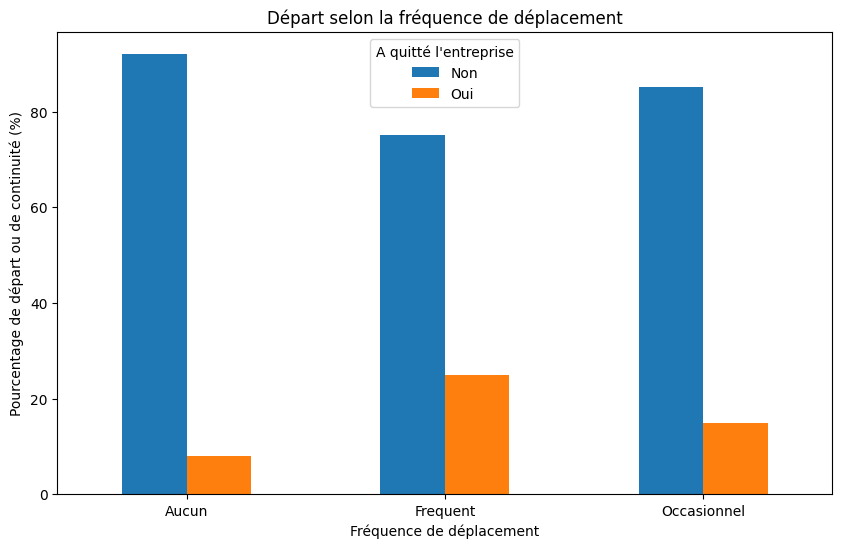

In [64]:
# relation entre a quitte l'entreprise et la frequence de deplacement (frequents départs pour les fréquents déplacemnts)
tableau_croise = pd.crosstab(extrait_sondage['frequence_deplacement'], 
                        extrait_sondage['a_quitte_l_entreprise'], 
                        normalize='index') * 100 

# Graphique en barres groupées
tableau_croise.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Fréquence de déplacement')
plt.ylabel('Pourcentage de départ ou de continuité (%)')
plt.title('Départ selon la fréquence de déplacement')
plt.legend(title='A quitté l\'entreprise')
plt.xticks(rotation=0)
plt.show()

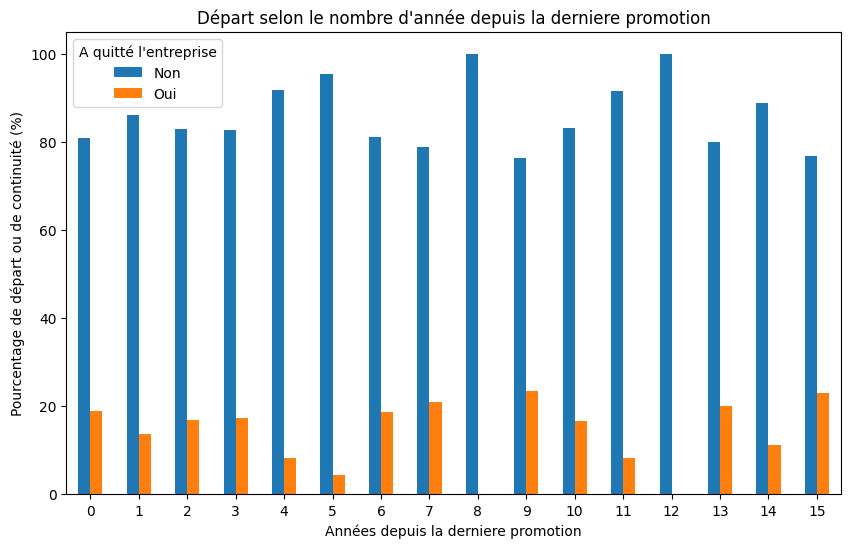

In [65]:
# relation entre a quitte l'entreprise et la frequence de deplacement
tableau_croise_2 = pd.crosstab(extrait_sondage['annees_depuis_la_derniere_promotion'], 
                        extrait_sondage['a_quitte_l_entreprise'], 
                        normalize='index') * 100

# Graphique en barres groupées
tableau_croise_2.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Années depuis la derniere promotion')
plt.ylabel('Pourcentage de départ ou de continuité (%)')
plt.title("Départ selon le nombre d'année depuis la derniere promotion")
plt.legend(title='A quitté l\'entreprise')
plt.xticks(rotation=0)
plt.show()

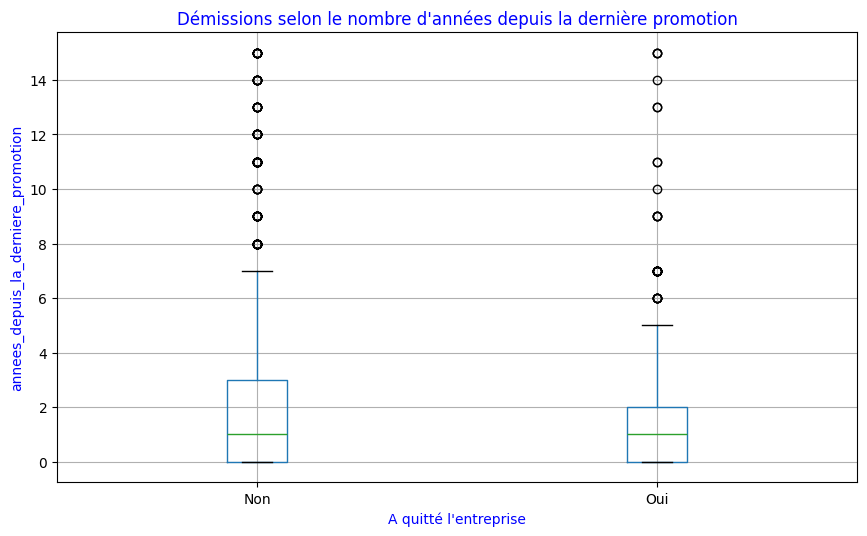

In [66]:
# ou bien sinon Boxplot
#Le manque de promotion n'est pas LE facteur principal de démission (médianes identiques)
#Certains employés partent malgré des promotions récentes (médiane à 1 an): promus récemment mais insatisfaits 
#des employés sont bloqués sans promotion depuis très longtemps (6/8-15 ans), certians restent mais d'autres partent (les "oubliés")
#la quartile Q3 est plus faible chez les démissionaires; 75% des partants le font au bout de 2 années sans promotion 
extrait_sondage.boxplot(column='annees_depuis_la_derniere_promotion', 
                         by='a_quitte_l_entreprise',
                         figsize=(10, 6))
plt.xlabel('A quitté l\'entreprise', color='blue')
plt.ylabel('annees_depuis_la_derniere_promotion', color='blue')
plt.title("Démissions selon le nombre d'années depuis la dernière promotion", color='blue')
plt.suptitle('')
plt.show()


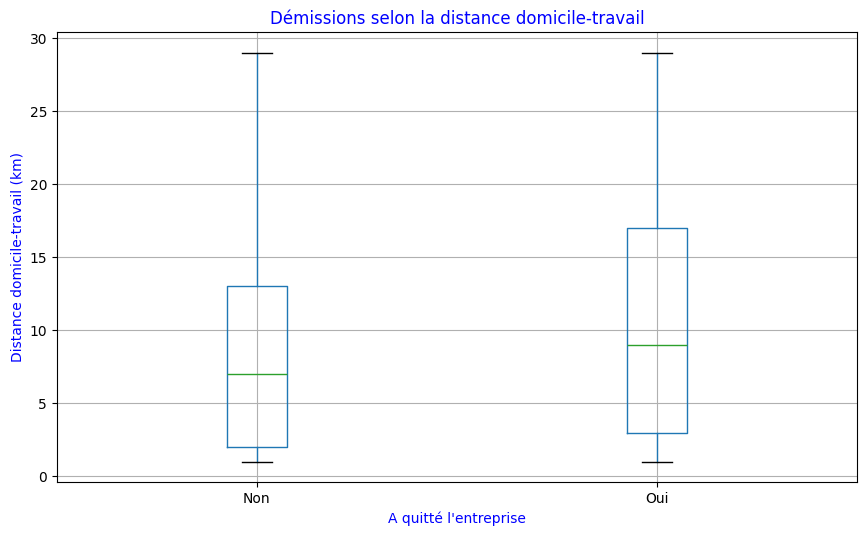

In [67]:
# boxplot
#Les employés qui quittent l'entreprise habitent généralement plus loin :
#La médiane est plus élevée
#L'intervalle interquartile est plus large, indiquant une plus grande variabilité
#Le quartile Q3 est plus élevé pour ceux qui quittent l'entreprise , ils font plus de kilomètres pour se rendre au travail
extrait_sondage.boxplot(column='distance_domicile_travail', 
                         by='a_quitte_l_entreprise', 
                         figsize=(10, 6))
plt.xlabel('A quitté l\'entreprise', color='blue')
plt.ylabel('Distance domicile-travail (km)', color='blue')
plt.title('Démissions selon la distance domicile-travail', color='blue')
plt.suptitle('')
plt.show()


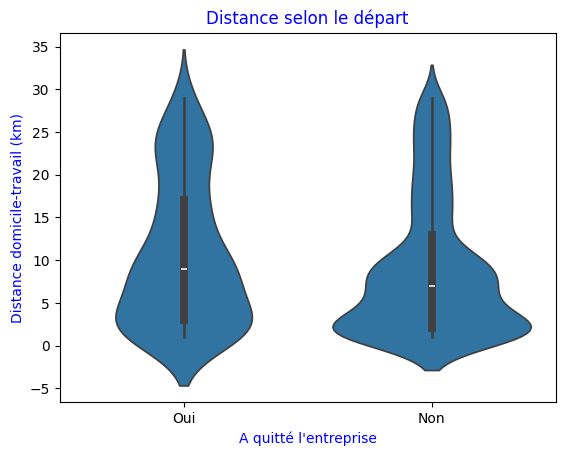

In [68]:
# ou bien, quel est le mieux ?
sns.violinplot(data=extrait_sondage, 
               x='a_quitte_l_entreprise', 
               y='distance_domicile_travail')
plt.xlabel('A quitté l\'entreprise', color='blue')
plt.ylabel('Distance domicile-travail (km)', color='blue')
plt.title('Distance selon le départ', color='blue')
plt.show()



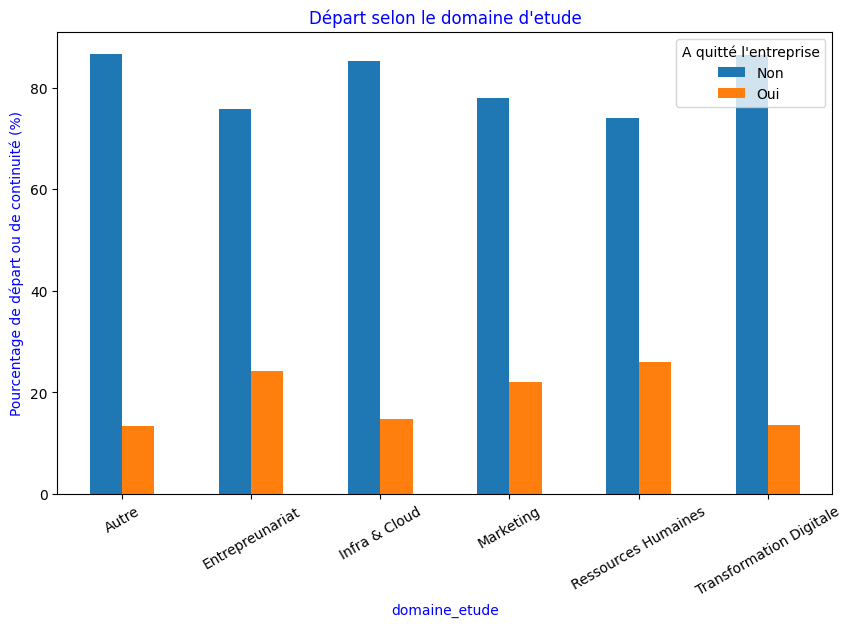

In [69]:
tableau_croise_domaine_etude = pd.crosstab(extrait_sondage['domaine_etude'], 
                        extrait_sondage['a_quitte_l_entreprise'], 
                        normalize='index') * 100 

tableau_croise_domaine_etude.plot(kind='bar', figsize=(10, 6))
plt.xlabel('domaine_etude', color='blue')
plt.ylabel('Pourcentage de départ ou de continuité (%)', color='blue')
plt.title("Départ selon le domaine d'etude", color='blue')
plt.legend(title='A quitté l\'entreprise')
plt.xticks(rotation=30)
plt.show()

In [70]:
print(extrait_eval['eval_number'].dtype)
print(extrait_eval['eval_number'].head())

object
0    E_1
1    E_2
2    E_4
3    E_5
4    E_7
Name: eval_number, dtype: object


In [71]:
#préparation de la fusion des 2 premiers dataframes
#convertion du type de données en entier
#on retire le préfixe "E_" et convertion en entier dans eval_number
# Convertion id_employee en entier aussi (au cas où)
extrait_eval['eval_number'] = extrait_eval['eval_number'].str.replace('E_', '').astype(int)
extrait_sirh['id_employee'] = extrait_sirh['id_employee'].astype(int)

In [72]:
print(extrait_eval['eval_number'].dtype)
print(extrait_eval['eval_number'].head())

int64
0    1
1    2
2    4
3    5
4    7
Name: eval_number, dtype: int64


In [73]:
print(extrait_sirh['id_employee'].dtype)
print(extrait_sirh['id_employee'].head())

int64
0    1
1    2
2    4
3    5
4    7
Name: id_employee, dtype: int64


In [74]:
# eval_number et id_employee ayant les mêmes valeurs en index, on peut renommer les colonnes identiquement
extrait_eval = extrait_eval.rename(columns={'eval_number': 'id_employee'})

In [75]:
# Fusion sur la même colonne (clé=id_employee)
fusion_eval_sirh = pd.merge(extrait_eval, extrait_sirh, on='id_employee')

In [76]:
fusion_eval_sirh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   satisfaction_employee_environnement        1470 non-null   int64 
 1   note_evaluation_precedente                 1470 non-null   int64 
 2   niveau_hierarchique_poste                  1470 non-null   int64 
 3   satisfaction_employee_nature_travail       1470 non-null   int64 
 4   satisfaction_employee_equipe               1470 non-null   int64 
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64 
 6   id_employee                                1470 non-null   int64 
 7   note_evaluation_actuelle                   1470 non-null   int64 
 8   heure_supplementaires                      1470 non-null   object
 9   augementation_salaire_precedente           1470 non-null   object
 10  age                                 

In [77]:
fusion_eval_sirh['id_employee'];

In [78]:
print(fusion_eval_sirh['id_employee'].dtype)
print(fusion_eval_sirh['id_employee'].head())

int64
0    1
1    2
2    4
3    5
4    7
Name: id_employee, dtype: int64


In [79]:
extrait_sondage['code_sondage'];

In [80]:
print(extrait_sondage['code_sondage'].dtype)
print(extrait_sondage['code_sondage'].head())

int64
0    1
1    2
2    4
3    5
4    7
Name: code_sondage, dtype: int64


In [81]:
# extrait_sondage et fusion_eval_sirh ayant les mêmes valeurs en index, on peut renommer les colonnes identiquement
extrait_sondage = extrait_sondage.rename(columns={'code_sondage': 'id_employee'})

In [82]:
# Fusion sur la même colonne (clé=id_employee)
fusion_totale = pd.merge(fusion_eval_sirh, extrait_sondage, on='id_employee')

In [83]:
fusion_totale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   satisfaction_employee_environnement        1470 non-null   int64 
 1   note_evaluation_precedente                 1470 non-null   int64 
 2   niveau_hierarchique_poste                  1470 non-null   int64 
 3   satisfaction_employee_nature_travail       1470 non-null   int64 
 4   satisfaction_employee_equipe               1470 non-null   int64 
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64 
 6   id_employee                                1470 non-null   int64 
 7   note_evaluation_actuelle                   1470 non-null   int64 
 8   heure_supplementaires                      1470 non-null   object
 9   augementation_salaire_precedente           1470 non-null   object
 10  age                                 

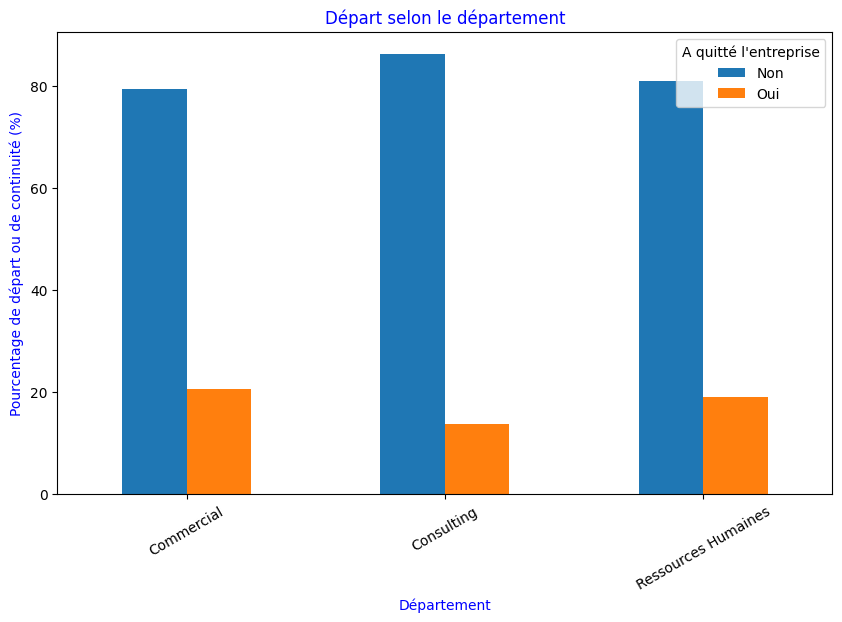

In [84]:
tableau_croise_departement = pd.crosstab(fusion_totale['departement'], 
                        fusion_totale['a_quitte_l_entreprise'], 
                        normalize='index') * 100 

tableau_croise_departement.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Département', color='blue')
plt.ylabel('Pourcentage de départ ou de continuité (%)', color='blue')
plt.title("Départ selon le département", color='blue')
plt.legend(title='A quitté l\'entreprise')
plt.xticks(rotation=30)
plt.show()

In [85]:
# On Crée 10 catégories de revenus ainsi qu'une nouvelle colonne d'une variable catégorielle ordonnée
fusion_totale['categorie_revenu'] = pd.qcut(fusion_totale['revenu_mensuel'], q=10)

In [86]:
#Compter les occurrences par catégorie et par départ
#tableau croisé qui compte combien de personnes ont quitté ou pas l'entreprise pour chaque catégorie de revenu
#size pour Compter le nombre de lignes dans chaque groupe-series
#unstack Transforme la Series en DataFrame
#fill_value=0 remplace les valeurs manquantes par 0 (si une combinaison n'existe pas)
comptage = fusion_totale.groupby(['categorie_revenu', 'a_quitte_l_entreprise']).size().unstack(fill_value=0)


C:\Users\chris\AppData\Local\Temp\ipykernel_18676\2634325575.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comptage = fusion_totale.groupby(['categorie_revenu', 'a_quitte_l_entreprise']).size().unstack(fill_value=0)


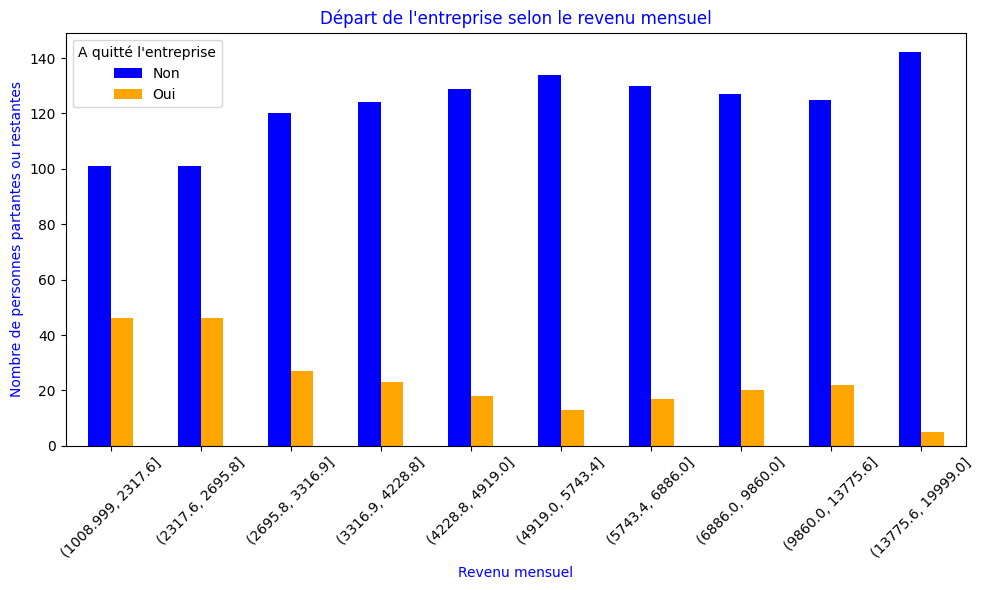

In [87]:
# Créer le graphique en barres groupées
comptage.plot(kind='bar', color=['blue', 'orange'], figsize=(10, 6))
plt.xlabel('Revenu mensuel', color='blue')
plt.ylabel('Nombre de personnes partantes ou restantes', color='blue')
plt.title('Départ de l\'entreprise selon le revenu mensuel', color='blue')
plt.legend(title='A quitté l\'entreprise', labels=['Non', 'Oui'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

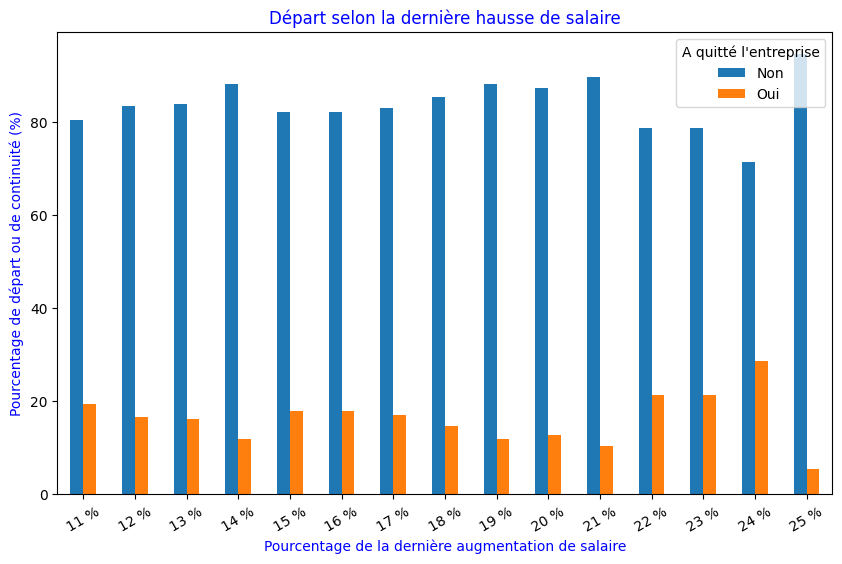

In [88]:
tableau_croise_augmentation_salaire = pd.crosstab(fusion_totale['augementation_salaire_precedente'], 
                        fusion_totale['a_quitte_l_entreprise'], 
                        normalize='index') * 100 

tableau_croise_augmentation_salaire.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Pourcentage de la dernière augmentation de salaire', color='blue')
plt.ylabel('Pourcentage de départ ou de continuité (%)', color='blue')
plt.title("Départ selon la dernière hausse de salaire", color='blue')
plt.legend(title='A quitté l\'entreprise')
plt.xticks(rotation=30)
plt.show()

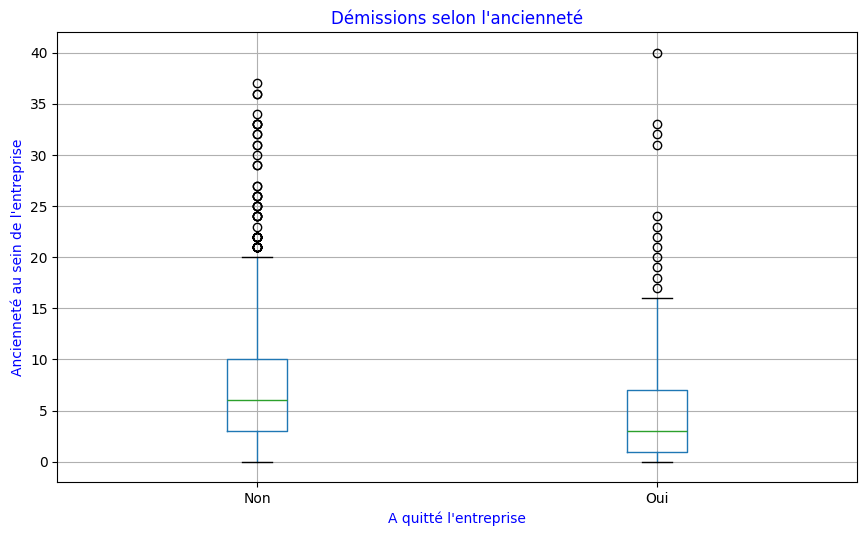

In [89]:
fusion_totale.boxplot(column='annees_dans_l_entreprise', 
                         by='a_quitte_l_entreprise', 
                         figsize=(10, 6))
plt.xlabel('A quitté l\'entreprise', color='blue')
plt.ylabel('Ancienneté au sein de l\'entreprise', color='blue')
plt.title("Démissions selon l'ancienneté", color='blue')
plt.suptitle('')
plt.show()

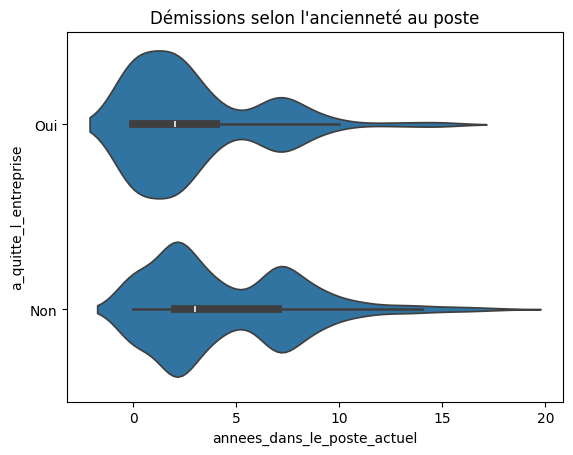

In [90]:
sns.violinplot(data=fusion_totale, 
               x='annees_dans_le_poste_actuel', 
               y='a_quitte_l_entreprise')
plt.title("Démissions selon l'ancienneté au poste")
plt.show()

In [91]:
#liste des colonnes
fusion_totale.columns.tolist();

In [92]:
# création d'une feature de progression professionnelle à partir de 2 variables quantitatives
# +1 pour éviter division par 0
fusion_totale['promotion_anciennete'] = (
    fusion_totale['annees_depuis_la_derniere_promotion'] / 
    (fusion_totale['annees_dans_l_entreprise'] + 1)*100)  


In [93]:
# création d'une feature de stabilité professionnelle à partir de 2 variables quantitatives
# +1 pour éviter division par 0
fusion_totale['score_stabilite'] = (
    fusion_totale['annees_dans_l_entreprise'] / 
    (fusion_totale['nombre_experiences_precedentes'] + 1))

In [94]:
print (fusion_totale['promotion_anciennete'])

0        0.000000
1        9.090909
2        0.000000
3       33.333333
4       66.666667
          ...    
1465     0.000000
1466    12.500000
1467     0.000000
1468     0.000000
1469    20.000000
Name: promotion_anciennete, Length: 1470, dtype: float64


In [95]:
print (fusion_totale['score_stabilite'])

0       0.666667
1       5.000000
2       0.000000
3       4.000000
4       0.200000
          ...   
1465    1.000000
1466    1.400000
1467    3.000000
1468    3.000000
1469    1.333333
Name: score_stabilite, Length: 1470, dtype: float64


In [96]:
#definition des features initiales
features=['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
          'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'id_employee', 'note_evaluation_actuelle',
          'heure_supplementaires', 'augementation_salaire_precedente', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement',
          'poste', 'nombre_experiences_precedentes', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
          'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'niveau_education', 'domaine_etude',
          'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'categorie_revenu','promotion_anciennete',
          'score_stabilite']

In [97]:
# on met de côté les variables numériques:

numeric_cols = ['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
                'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'age', 'revenu_mensuel',
                'nombre_experiences_precedentes', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
                'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'niveau_education',
                'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel','promotion_anciennete', 'score_stabilite']

In [98]:
# matrice de correlation Pearson des variables numériques
corr_matrice_features_numeriques = fusion_totale[numeric_cols].corr()

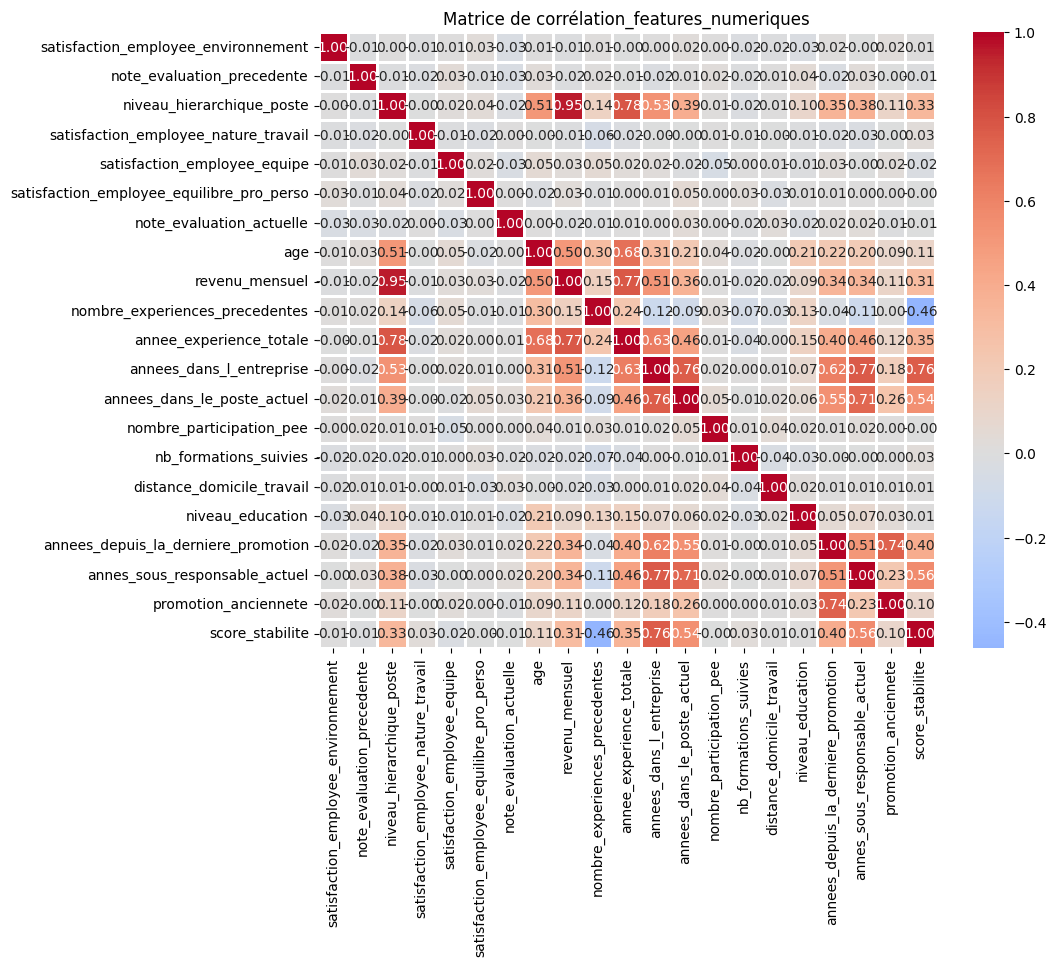

In [99]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrice_features_numeriques, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Matrice de corrélation_features_numeriques')
plt.show()

In [100]:
# niveau hiérarchique et revenu mensuel sont corrélées=>suppression colonne niv hierarchique
# niveau hiérarchique et annee experience totale corrélées=>OK
# revenu mensuel et annee experience totale corrélées =>suppression colonne annee experience totale
# annee dans l entreprise et annee dans le poste actuel corrélées=>suppression colonne annee dans le poste actuel
# annee dans l entreprise et annee sous responsable actuel corrélées=>suppression colonne annee sous responsable actuel
# année dans le poste actuel et annee sous responsable actuel correlées=>OK
# promotion ancienneté corrélée avec annee depuis la derniere promotion=>suppression de promotion ancienneté
# score stabilite corrélée avec annee dans l entreprise=> suppression de score stabilite

In [101]:
fusion_totale.drop(columns=['niveau_hierarchique_poste','annee_experience_totale','annees_dans_le_poste_actuel','annes_sous_responsable_actuel',
                            'promotion_anciennete', 'score_stabilite'], inplace=True)

In [102]:
fusion_totale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 26 columns):
 #   Column                                     Non-Null Count  Dtype   
---  ------                                     --------------  -----   
 0   satisfaction_employee_environnement        1470 non-null   int64   
 1   note_evaluation_precedente                 1470 non-null   int64   
 2   satisfaction_employee_nature_travail       1470 non-null   int64   
 3   satisfaction_employee_equipe               1470 non-null   int64   
 4   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64   
 5   id_employee                                1470 non-null   int64   
 6   note_evaluation_actuelle                   1470 non-null   int64   
 7   heure_supplementaires                      1470 non-null   object  
 8   augementation_salaire_precedente           1470 non-null   object  
 9   age                                        1470 non-null   int64   
 10  genre       

In [103]:
#definition des features après suppression des corrélations
features_new=['satisfaction_employee_environnement', 'note_evaluation_precedente', 'satisfaction_employee_nature_travail',
          'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'id_employee', 'note_evaluation_actuelle',
          'heure_supplementaires', 'augementation_salaire_precedente', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement',
          'poste', 'nombre_experiences_precedentes', 'annees_dans_l_entreprise',
          'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'niveau_education', 'domaine_etude',
          'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'categorie_revenu']

In [104]:
#features numériques après suppression des corrélations
numeric_cols_new = ['satisfaction_employee_environnement', 'note_evaluation_precedente', 'satisfaction_employee_nature_travail',
                'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'age', 'revenu_mensuel',
                'nombre_experiences_precedentes', 'annees_dans_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 
                'distance_domicile_travail', 'niveau_education', 'annees_depuis_la_derniere_promotion']

In [105]:
#definition de la variable cible
y = fusion_totale['a_quitte_l_entreprise'].copy()
print(f"y avant encodage: {y.shape}")
print(f"Valeurs: {y.unique()}")

y avant encodage: (1470,)
Valeurs: ['Oui' 'Non']


In [106]:
# On définit le mapping pour y
mapping_cible = {'Non': 0, 'Oui': 1}

y_encoded = y.map(mapping_cible)

In [107]:
y = pd.Series(y_encoded, index=y.index, name='a_quitte_l_entreprise')

In [108]:
print(y)

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: a_quitte_l_entreprise, Length: 1470, dtype: int64


In [109]:
X = fusion_totale[features_new].copy()

In [110]:
# on fait attention aux espaces dans la variable des hausses de salaires
X['augementation_salaire_precedente'] = X['augementation_salaire_precedente'].str.strip().str.replace(' ', '')

In [111]:
# on Définit les colonnes catégorielles à encoder par catégories pour privilégier les relations ordinales
ordinal_categories = {
    'augementation_salaire_precedente': ['11%', '12%', '13%', '14%', '15%', '16%', '17%', '18%', '19%', '20%', '21%', '22%',
                                         '23%', '24%', '25%'],
    'frequence_deplacement': ['Aucun', 'Occasionnel', 'Frequent']}

binary_cols = ['heure_supplementaires', 'genre']

nominal_cols = ['statut_marital', 'departement', 'poste', 'domaine_etude']



In [112]:
# on crée le ColumnTransformer qui coordonne plusieurs encodeurs en une seule fois.
# OrdinalEncoder sur les variables ordinales (en gardant un odre specifique logique quand il le faut-sinon par ordre alphabetique)
# OneHotEncoder sur les variables nominales-catégorielles sans ordre (on laisse la 1ere colonne qui est expliquée par les autres;
## pas de compression par défaut de la mémoire sparse du OneHotEncoder pour créer le dataframe X après tranformation).
# outliers sur les variables quantitatives, normalisation avec RobustScaler sur la mediane et l'IQR plutôt que la moyenne
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal_sal', OrdinalEncoder(categories=[ordinal_categories['augementation_salaire_precedente']]), 
         ['augementation_salaire_precedente']),
        
        ('ordinal_freq', OrdinalEncoder(categories=[ordinal_categories['frequence_deplacement']]), 
         ['frequence_deplacement']),
        
        ('binary', OrdinalEncoder(), binary_cols),
        
        ('nominal', OneHotEncoder(drop='first', sparse_output=False), nominal_cols),
        ('numeric', RobustScaler(), numeric_cols_new)])

In [113]:
# on Transforme X en np.array (sans nom de colonnes)
X_transformed = preprocessor.fit_transform(X)

In [114]:
# On Reconvertit le X series en DataFrame avec noms de colonnes (apparaît en nom de type de transformation: binaire, ordinale, ...)
# renomme les colonnes après transformation pour plus de lisibilité
# on garde les mêmes index
X_final = pd.DataFrame(
    X_transformed,
    columns=preprocessor.get_feature_names_out(),
    index=X.index)



In [115]:
print(X_final.shape)
print(X_final.columns)

(1470, 36)
Index(['ordinal_sal__augementation_salaire_precedente',
       'ordinal_freq__frequence_deplacement', 'binary__heure_supplementaires',
       'binary__genre', 'nominal__statut_marital_Divorcé(e)',
       'nominal__statut_marital_Marié(e)', 'nominal__departement_Consulting',
       'nominal__departement_Ressources Humaines',
       'nominal__poste_Cadre Commercial', 'nominal__poste_Consultant',
       'nominal__poste_Directeur Technique', 'nominal__poste_Manager',
       'nominal__poste_Représentant Commercial',
       'nominal__poste_Ressources Humaines', 'nominal__poste_Senior Manager',
       'nominal__poste_Tech Lead', 'nominal__domaine_etude_Entrepreunariat',
       'nominal__domaine_etude_Infra & Cloud',
       'nominal__domaine_etude_Marketing',
       'nominal__domaine_etude_Ressources Humaines',
       'nominal__domaine_etude_Transformation Digitale',
       'numeric__satisfaction_employee_environnement',
       'numeric__note_evaluation_precedente',
       'numeric_

In [116]:
# on enlève les préfixes des colonnes crées par le transformer pour renommer les colonnes comme les originales
X_final.columns = [
    col.replace('ordinal_sal__', '')
       .replace('ordinal_freq__', '')
       .replace('binary__', '')
       .replace('nominal__', '')
       .replace('numeric__', '')
    for col in X_final.columns
]

print(X_final.columns)

Index(['augementation_salaire_precedente', 'frequence_deplacement',
       'heure_supplementaires', 'genre', 'statut_marital_Divorcé(e)',
       'statut_marital_Marié(e)', 'departement_Consulting',
       'departement_Ressources Humaines', 'poste_Cadre Commercial',
       'poste_Consultant', 'poste_Directeur Technique', 'poste_Manager',
       'poste_Représentant Commercial', 'poste_Ressources Humaines',
       'poste_Senior Manager', 'poste_Tech Lead',
       'domaine_etude_Entrepreunariat', 'domaine_etude_Infra & Cloud',
       'domaine_etude_Marketing', 'domaine_etude_Ressources Humaines',
       'domaine_etude_Transformation Digitale',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'age', 'revenu_mensuel', 'nombre_experiences_precedentes',
       'annees_dans_l_entreprise', 'nombre_particip

In [117]:
#séparation en jeu d'apprentissage et jeu de test avec parametres classiques (20% test, 80% train et random size à 42)
# on conserve les mêmes proportions de classe (majoritaire et minoritaire) entre le train et le test (stratify=y); tous les modèles pourront être testés
# sur le MÊME test set
X_final_train, X_final_test, y_train, y_test = train_test_split(X_final, y, test_size=0.20, random_state=42,stratify=y) 

In [118]:
# On Crée et entraîne le modèle de base Dummy (prédiction de la base majoritaire, ici ce sera" 0") pour voir ses résultats 
# et le comparer aux autres modèles ensuite
# Dummy ne s'occupe que de y_train pour regarder la distribution de y; pas de gestion réelle des features avec Dummy
# entrainement du modele
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_final_train, y_train)



,strategy,'most_frequent'
,random_state,None
,constant,None


In [119]:
# Les prédictions
y_pred_dummy_train = dummy_clf.predict(X_final_train)
y_pred_dummy_test = dummy_clf.predict(X_final_test)



In [120]:
# Évaluons les performances du modèle de base Dummy

print("\n Performance sur TRAIN ")
print(f"Dummy_Accuracy (Exactitude): {accuracy_score(y_train, y_pred_dummy_train):.4f}")

print("\n Performance sur TEST ")
print(f"Dummy_Accuracy (Exactitude): {accuracy_score(y_test, y_pred_dummy_test):.4f}")

print("\n Classification Report (TEST) ")
print(classification_report(y_test, y_pred_dummy_test, 
                          target_names=['Non quitté (0)', 'A Quitté (1)']))


 Performance sur TRAIN 
Dummy_Accuracy (Exactitude): 0.8384

 Performance sur TEST 
Dummy_Accuracy (Exactitude): 0.8401

 Classification Report (TEST) 
                precision    recall  f1-score   support

Non quitté (0)       0.84      1.00      0.91       247
  A Quitté (1)       0.00      0.00      0.00        47

      accuracy                           0.84       294
     macro avg       0.42      0.50      0.46       294
  weighted avg       0.71      0.84      0.77       294



C:\Users\chris\AppData\Local\pypoetry\Cache\virtualenvs\classification-auto-des-informations-Cx0GgdV--py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\chris\AppData\Local\pypoetry\Cache\virtualenvs\classification-auto-des-informations-Cx0GgdV--py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\chris\AppData\Local\pypoetry\Cache\virtualenvs\classification-auto-des-informations-Cx0GgdV--py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricW

In [121]:
# Performance du modèle Dummy:
# ("Non"="0") est majoritaire, le modèle prédit la classe la plus importante et oublie l'autre classe
# la précision est bonne pour les Non mais nulle pour les Oui car le modele ne predit pas les Oui
# le recall est à 100% sur les Non (100% des Non n'ont pas quitté) et 0% sur les Oui (pas de détection de ceux qui ont quitté)

In [122]:
print("\n Matrice de confusion (TEST) ")
cm = confusion_matrix(y_test, y_pred_dummy_test)
cm_df = pd.DataFrame(cm, 
                     index=['Réel: Non (0)', 'Réel: Oui (1)'],
                     columns=['Prédit: Non (0)', 'Prédit: Oui (1)'])
print(cm_df)



 Matrice de confusion (TEST) 
               Prédit: Non (0)  Prédit: Oui (1)
Réel: Non (0)              247                0
Réel: Oui (1)               47                0


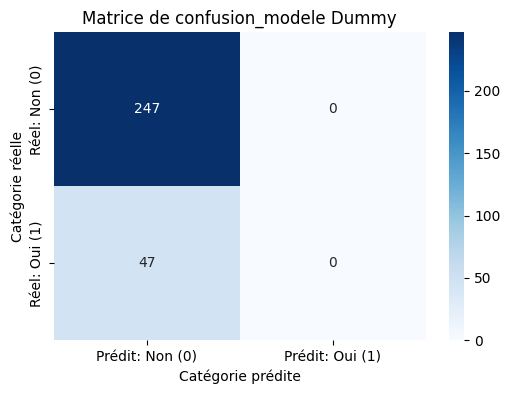

In [123]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Non (0)', 'Prédit: Oui (1)'],
            yticklabels=['Réel: Non (0)', 'Réel: Oui (1)'])
plt.title("Matrice de confusion_modele Dummy")
plt.ylabel("Catégorie réelle")
plt.xlabel("Catégorie prédite")
plt.show()

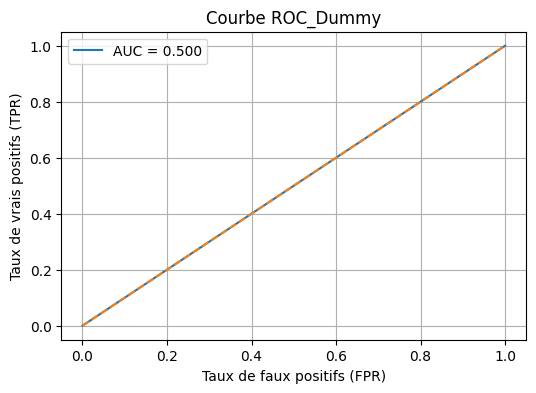

In [124]:
#Tracé de la courbe ROC et calcul de l'AUC

#probabilité sur la classe "Oui (1)"
y_scores = dummy_clf.predict_proba(y_test)[:, 1]

# Calcul des coordonnées ROC (recall ou TPR-vrais positifs par rapport au FPR-faux positifs)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Aire sous la courbe (AUC)
# ici le modèle Dummy est mauvais car l'AUC est éloigné de 1
roc_auc = auc(fpr, tpr)

# Tracé de la courbe ROC avec la diagonale aléatoire en pointillé
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC_Dummy')
plt.legend()
plt.grid(True)
plt.show()

In [125]:
# interprétation de la Courbe ROC: on a ici une diagonale pour ce modèle Dummy
# AUC=0.5

In [126]:
# modele de forêt aléatoire
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
# entrainement du modele
random_forest .fit(X_final_train, y_train)
# predictions du modele
y_pred_random_forest_test = random_forest.predict(X_final_test) 
y_pred_random_forest_train = random_forest.predict(X_final_train)
 

In [127]:
print("\n Performance sur TRAIN ")
print(f"Random_Forest_Accuracy : {accuracy_score(y_train, y_pred_random_forest_train):.4f}")

print("\n Performance sur TEST ")
print(f"Random_Forest_Accuracy : {accuracy_score(y_test, y_pred_random_forest_test):.4f}")

print("\n Classification Report (TEST) ")
print(classification_report(y_test, y_pred_random_forest_test, 
                          target_names=['Non quitté (0)', 'A Quitté (1)']))


 Performance sur TRAIN 
Random_Forest_Accuracy : 1.0000

 Performance sur TEST 
Random_Forest_Accuracy : 0.8435

 Classification Report (TEST) 
                precision    recall  f1-score   support

Non quitté (0)       0.85      0.99      0.91       247
  A Quitté (1)       0.57      0.09      0.15        47

      accuracy                           0.84       294
     macro avg       0.71      0.54      0.53       294
  weighted avg       0.81      0.84      0.79       294



In [128]:
# Matrice de confusion pour voir combien de départs sont détectés et Identifier les faux positifs vs faux négatifs
print("\n Matrice de confusion (TEST) ")
cm_random_forest = confusion_matrix(y_test, y_pred_random_forest_test)
cm_random_forest_df = pd.DataFrame(cm_random_forest, 
                     index=['Réel: Non (0)', 'Réel: Oui (1)'],
                     columns=['Prédit: Non (0)', 'Prédit: Oui (1)'])
print(cm_df)


 Matrice de confusion (TEST) 
               Prédit: Non (0)  Prédit: Oui (1)
Réel: Non (0)              247                0
Réel: Oui (1)               47                0


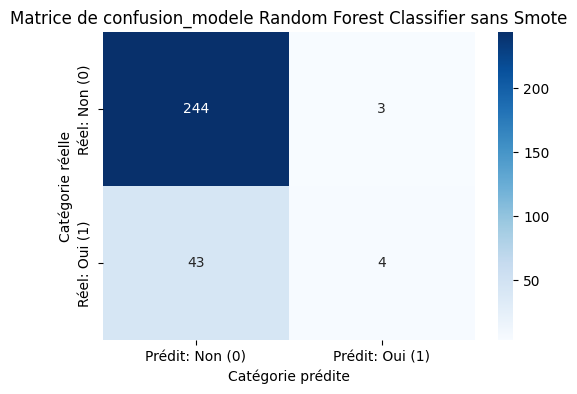

In [129]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_random_forest, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Non (0)', 'Prédit: Oui (1)'],
            yticklabels=['Réel: Non (0)', 'Réel: Oui (1)'])
plt.title("Matrice de confusion_modele Random Forest Classifier sans Smote")
plt.ylabel("Catégorie réelle")
plt.xlabel("Catégorie prédite")
plt.show()

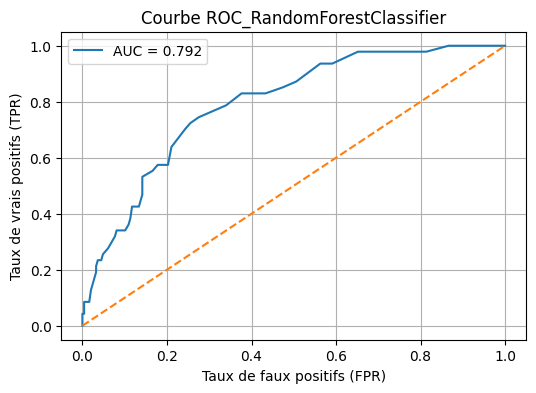

In [130]:
#Tracé de la courbe ROC et calcul de l'AUC

#probabilités sur la classe "Oui (1)"
y_proba_rf = random_forest.predict_proba(X_final_test)[:, 1]

# Calcul des coordonnées ROC (recall ou TPR-vrais positifs par rapport au FPR-faux positifs)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

# Aire sous la courbe (AUC)
roc_auc = auc(fpr, tpr)

# Tracé de la courbe ROC avec la diagonale aléatoire en pointillé
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--') 

plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC_RandomForestClassifier')
plt.legend()
plt.grid(True)
plt.show()

In [131]:
# La Courbe ROC en forêt aléatoire se rapproche de l'axe (0,1) vs la Courbe en modèle Dummy
# L'aire AUC est supérieure avec la forêt aléatoire vs l'AUC du Dummy
# =>les features sont cohérentes pour expliquer la variable cible


Average Precision (AP) Score: 0.4244
Baseline-proportion de la classe minoritaire : 0.1599
 Si AP > 0.1599, le modèle est meilleur que la baseline



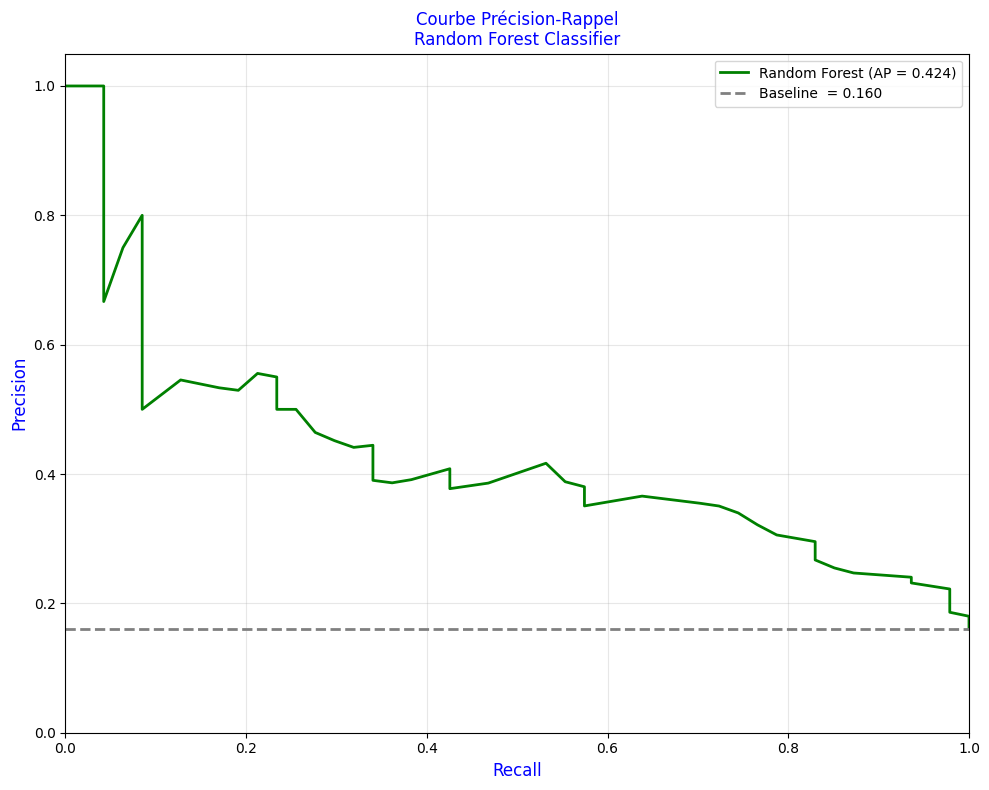

In [132]:
# Preparation de la Courbe PR (Prévision-Rappel) 
# pour voir le compromis Précision/Recall et choisir le seuil optimal 
y_proba_rf = random_forest.predict_proba(X_final_test)[:, 1]

# Calcul de la courbe Précision-Rappel
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)

# Calcul de l'Average Precision (AP) 
ap_score = average_precision_score(y_test, y_proba_rf)

print(f"\nAverage Precision (AP) Score: {ap_score:.4f}")

# Calcul de la baseline (proportion de la classe minoritaire sur le test set)
baseline = (y_test == 1).sum() / len(y_test)
print(f"Baseline-proportion de la classe minoritaire : {baseline:.4f}")
print(f" Si AP > {baseline:.4f}, le modèle est meilleur que la baseline\n")

# Traçage de la courbe Précision-Rappel
plt.figure(figsize=(10, 8))

# Courbe du modèle
plt.plot(recall, precision, color='green', lw=2, 
         label=f'Random Forest (AP = {ap_score:.3f})')

# Ligne de baseline (modèle aléatoire)
plt.plot([0, 1], [baseline, baseline], linestyle='--', color='gray', lw=2,
         label=f'Baseline  = {baseline:.3f}')

plt.xlabel('Recall', color='blue', fontsize=12)
plt.ylabel('Precision', color='blue', fontsize=12)
plt.title('Courbe Précision-Rappel\nRandom Forest Classifier', color='blue')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

In [133]:
# RÉGRESSION LOGISTIQUE 
print("\n RÉGRESSION LOGISTIQUE ")

logreg = LogisticRegression(max_iter=1000, random_state=42)

# entraînement du modèle avec Smote
logreg.fit(X_final_train, y_train)  

#predictions sur le test set
y_pred_logreg= logreg.predict(X_final_test)
y_proba_logreg = logreg.predict_proba(X_final_test)[:, 1]

#calcul des métriques sur test set:

acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_proba_logreg)

print(f"Accuracy TEST: {acc_logreg:.4f} ({acc_logreg*100:.2f}%)")
print(f"ROC-AUC TEST:  {auc_logreg:.4f}")

print("\n--- Classification Report (TEST) ---")
print(classification_report(y_test, y_pred_logreg,
                          target_names=['Non quitté (0)', 'A Quitté (1)']))


 RÉGRESSION LOGISTIQUE 
Accuracy TEST: 0.8673 (86.73%)
ROC-AUC TEST:  0.8162

--- Classification Report (TEST) ---
                precision    recall  f1-score   support

Non quitté (0)       0.89      0.96      0.92       247
  A Quitté (1)       0.65      0.36      0.47        47

      accuracy                           0.87       294
     macro avg       0.77      0.66      0.70       294
  weighted avg       0.85      0.87      0.85       294



In [134]:
# Pour ré-équilibrer les classes on va importer et utiliser les modules de imblearn

In [135]:
#### On va utiliser le module SMOTE pour équilibrer les 2 classes (majoritaires et minoritaires)###
smote = SMOTE(random_state=42)

In [136]:
X_train_resampled, y_train_resampled = smote.fit_resample(X_final_train, y_train)

In [137]:
print(f"\n APRÈS SMOTE:")
print(f"  X_train_resampled shape: {X_train_resampled.shape}")
print(f"  y_train_resampled shape: {y_train_resampled.shape}")
print(f"  Classe 0: {(y_train_resampled==0).sum()}")
print(f"  Classe 1: {(y_train_resampled==1).sum()}")


 APRÈS SMOTE:
  X_train_resampled shape: (1972, 36)
  y_train_resampled shape: (1972,)
  Classe 0: 986
  Classe 1: 986


In [138]:
print("\n MODÈLE: RANDOM FOREST (AVEC SMOTE sur test set)")

# entraînement du modèle avec SMOTE
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_resampled, y_train_resampled) 

#prédictions sur le test set:
y_pred_rf_smote = rf_smote.predict(X_final_test)
y_proba_rf_smote = rf_smote.predict_proba(X_final_test)[:, 1]

#calculs des métriques sur test set:
acc_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
auc_rf_smote = roc_auc_score(y_test, y_proba_rf_smote)

print(f"Accuracy Test set: {acc_rf_smote:.4f}")
print(f"ROC-AUC test set:  {auc_rf_smote:.4f}")

print("\n--- Classification Report (Test set) ---")
print(classification_report(y_test, y_pred_rf_smote,
                          target_names=['Non quitté (0)', 'A Quitté (1)']))




 MODÈLE: RANDOM FOREST (AVEC SMOTE sur test set)
Accuracy Test set: 0.8605
ROC-AUC test set:  0.7843

--- Classification Report (Test set) ---
                precision    recall  f1-score   support

Non quitté (0)       0.87      0.98      0.92       247
  A Quitté (1)       0.67      0.26      0.37        47

      accuracy                           0.86       294
     macro avg       0.77      0.62      0.65       294
  weighted avg       0.84      0.86      0.83       294



In [139]:
print("\n Matrice de confusion (TEST) ")
cm_random_forest_smote = confusion_matrix(y_test, y_pred_rf_smote)
cm_random_forest_df = pd.DataFrame(cm_random_forest_smote, 
                     index=['Réel: Non (0)', 'Réel: Oui (1)'],
                     columns=['Prédit: Non (0)', 'Prédit: Oui (1)'])
print(cm_df)


 Matrice de confusion (TEST) 
               Prédit: Non (0)  Prédit: Oui (1)
Réel: Non (0)              247                0
Réel: Oui (1)               47                0


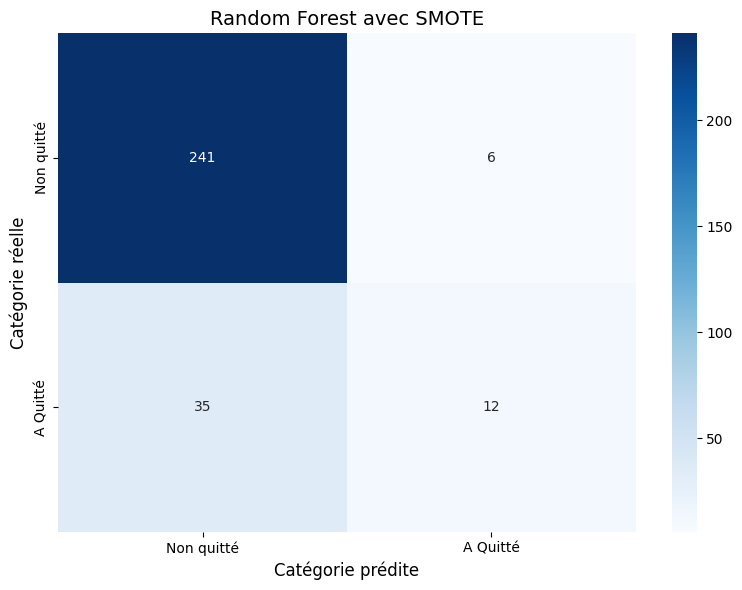

In [140]:
# matrices de confusion sur Random Forest avec SMOTE:
cm_random_forest_smote = confusion_matrix(y_test, y_pred_rf_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_random_forest_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non quitté', 'A Quitté'],
            yticklabels=['Non quitté', 'A Quitté'])
plt.title('Random Forest avec SMOTE', fontsize=14)
plt.ylabel('Catégorie réelle', fontsize=12)
plt.xlabel('Catégorie prédite', fontsize=12)

plt.tight_layout()
plt.show()

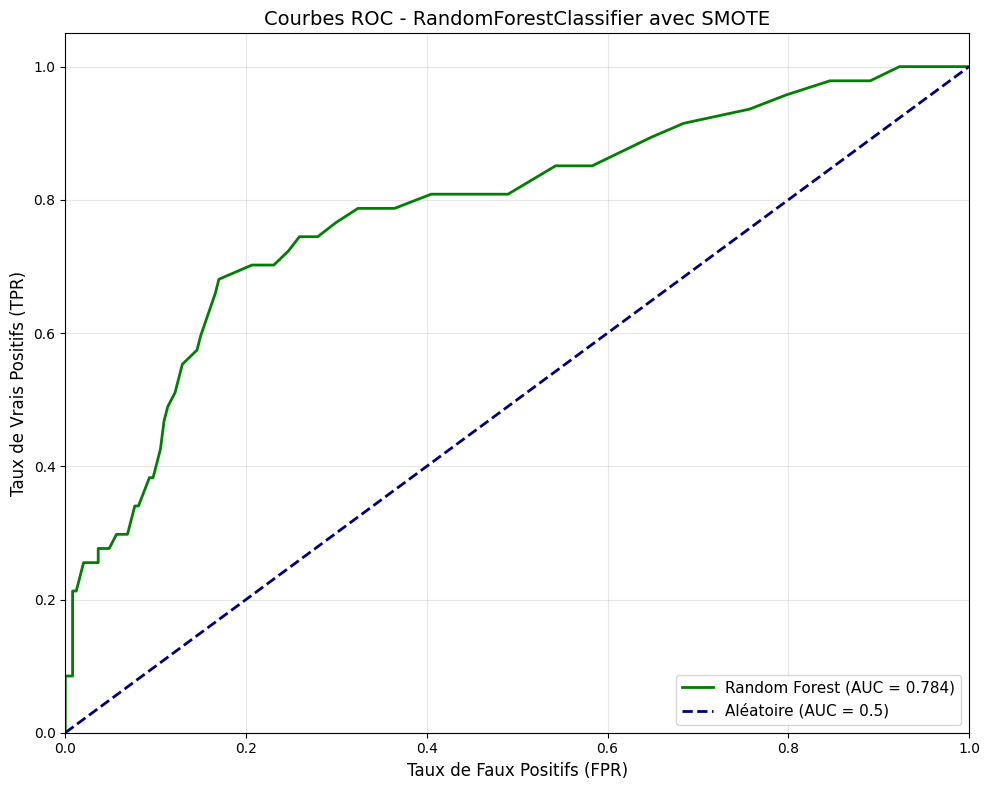

In [141]:
# Calculer la courbe ROC de random forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf_smote)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Traçage de la Courbe
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2,
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Aléatoire (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - RandomForestClassifier avec SMOTE', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Average Precision (AP) Score: 0.4899
Baseline (No Skill): 0.1599
   Si AP > 0.1599, le modèle est meilleur que la baseline



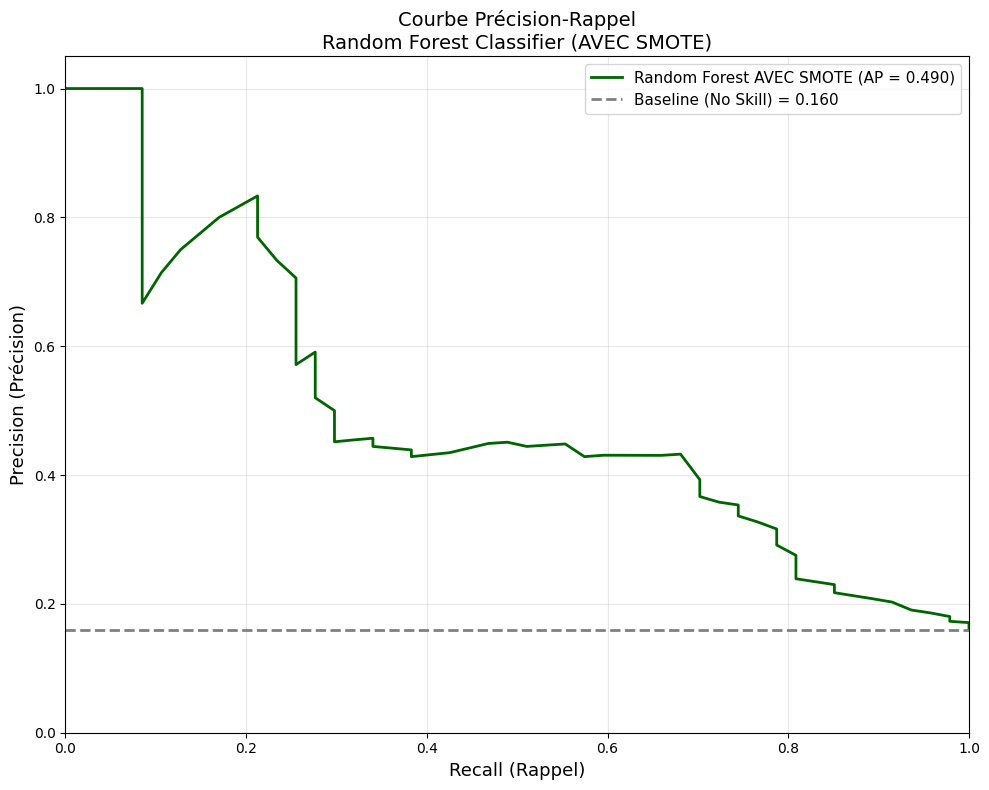

In [142]:
# Calcul de la courbe Précision-Rappel
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf_smote)

# Calcul de l'Average Precision (AP)
ap_score = average_precision_score(y_test, y_proba_rf_smote)
print(f"Average Precision (AP) Score: {ap_score:.4f}")

# Calcul de la baseline
baseline = (y_test == 1).sum() / len(y_test)
print(f"Baseline (No Skill): {baseline:.4f}")
print(f"   Si AP > {baseline:.4f}, le modèle est meilleur que la baseline\n")

# Traçage de la courbe Précision-Rappel
plt.figure(figsize=(10, 8))

# Courbe du modèle
plt.plot(recall, precision, color='darkgreen', lw=2, label=f'Random Forest AVEC SMOTE (AP = {ap_score:.3f})')

# Ligne de baseline
plt.plot([0, 1], [baseline, baseline], linestyle='--', color='gray', lw=2, label=f'Baseline (No Skill) = {baseline:.3f}')

plt.xlabel('Recall (Rappel)', fontsize=13)
plt.ylabel('Precision (Précision)', fontsize=13)
plt.title('Courbe Précision-Rappel\nRandom Forest Classifier (AVEC SMOTE)', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

In [143]:
# Prédictions du modèle random forest avec SMOTE sur train set
y_pred_train = rf_smote.predict(X_train_resampled)
y_proba_train = rf_smote.predict_proba(X_train_resampled)[:, 1]

# calcul des Métriques sur random forest avec SMOTE en train set
print("\n PERFORMANCES SUR TRAIN (avec SMOTE)")
acc_train = accuracy_score(y_train_resampled, y_pred_train)
auc_train = roc_auc_score(y_train_resampled, y_proba_train)
print(f"Accuracy: {acc_train:.4f}")
print(f"ROC-AUC:  {auc_train:.4f}")



 PERFORMANCES SUR TRAIN (avec SMOTE)
Accuracy: 1.0000
ROC-AUC:  1.0000


In [144]:
# Difference de l'accuracy entre Train et test:
acc_train_vs_test=(acc_train - acc_rf_smote)
print(acc_train_vs_test)

0.1394557823129252


In [145]:
#le modele de random forest avec Smote: Accuracy avec train > Accuracy avec test => les échantillons sont mieux classés avec le train set:overfit

In [146]:
# RÉGRESSION LOGISTIQUE avec SMOTE
print("\n RÉGRESSION LOGISTIQUE (AVEC SMOTE)")

logreg_smote = LogisticRegression(max_iter=1000, random_state=42)

# entraînement du modèle avec Smote
logreg_smote.fit(X_train_resampled, y_train_resampled)  

#predictions sur le test set
y_pred_logreg_smote = logreg_smote.predict(X_final_test)
y_proba_logreg_smote = logreg_smote.predict_proba(X_final_test)[:, 1]

#calcul des métriques sur test set:

acc_logreg_smote = accuracy_score(y_test, y_pred_logreg_smote)
auc_logreg_smote = roc_auc_score(y_test, y_proba_logreg_smote)

print(f"Accuracy TEST: {acc_logreg_smote:.4f} ({acc_logreg_smote*100:.2f}%)")
print(f"ROC-AUC TEST:  {auc_logreg_smote:.4f}")

print("\n--- Classification Report (TEST) ---")
print(classification_report(y_test, y_pred_logreg_smote,
                          target_names=['Non quitté (0)', 'A Quitté (1)']))



 RÉGRESSION LOGISTIQUE (AVEC SMOTE)
Accuracy TEST: 0.7993 (79.93%)
ROC-AUC TEST:  0.8156

--- Classification Report (TEST) ---
                precision    recall  f1-score   support

Non quitté (0)       0.93      0.82      0.87       247
  A Quitté (1)       0.42      0.68      0.52        47

      accuracy                           0.80       294
     macro avg       0.68      0.75      0.70       294
  weighted avg       0.85      0.80      0.82       294



In [147]:
# Matrice de confusion - Régression Logistique avec SMOTE
cm_logreg = confusion_matrix(y_test, y_pred_logreg_smote)
cm_logreg_df = pd.DataFrame(cm_logreg, 
                     index=['Réel: Non (0)', 'Réel: Oui (1)'],
                     columns=['Prédit: Non (0)', 'Prédit: Oui (1)'])
print(cm_logreg_df)


               Prédit: Non (0)  Prédit: Oui (1)
Réel: Non (0)              203               44
Réel: Oui (1)               15               32


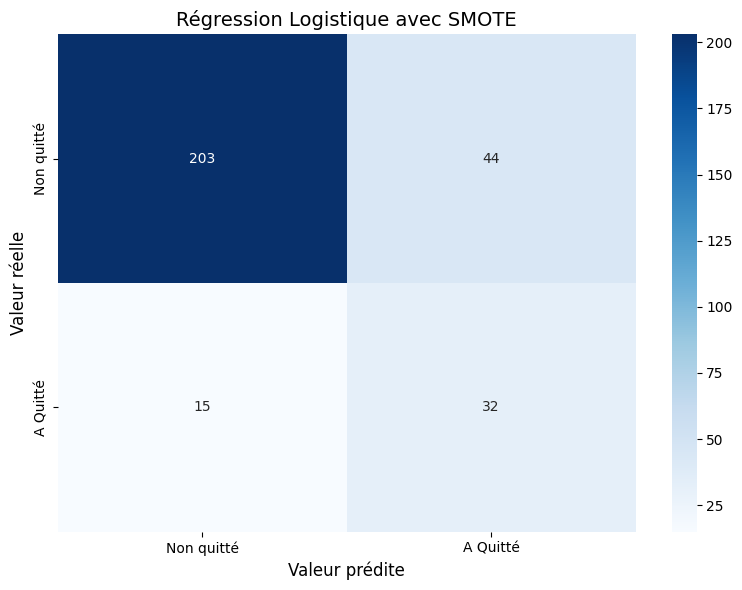

In [148]:
#traçage de la Courbe
cm_logreg = confusion_matrix(y_test, y_pred_logreg_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non quitté', 'A Quitté'],
            yticklabels=['Non quitté', 'A Quitté'])
plt.title('Régression Logistique avec SMOTE', fontsize=14)
plt.ylabel('Valeur réelle', fontsize=12)
plt.xlabel('Valeur prédite', fontsize=12)
plt.tight_layout()
plt.show()


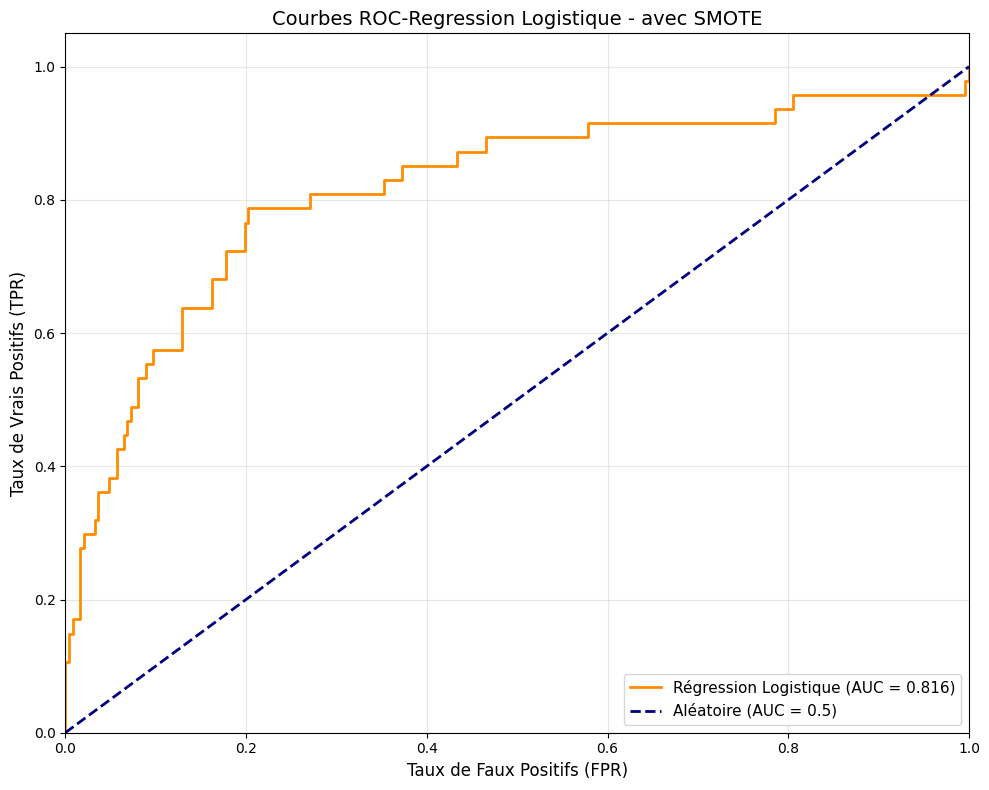

In [149]:
# Calcul de la courbe ROC
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg_smote)

roc_auc_logreg = auc(fpr_logreg, tpr_logreg)


# Traçage
plt.figure(figsize=(10, 8))
plt.plot(fpr_logreg, tpr_logreg, color='darkorange', lw=2,
         label=f'Régression Logistique (AUC = {roc_auc_logreg:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Aléatoire (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC-Regression Logistique - avec SMOTE', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Average Precision (AP) - Régression Logistique:
  AVEC SMOTE: 0.5611

 VISUALISATION 


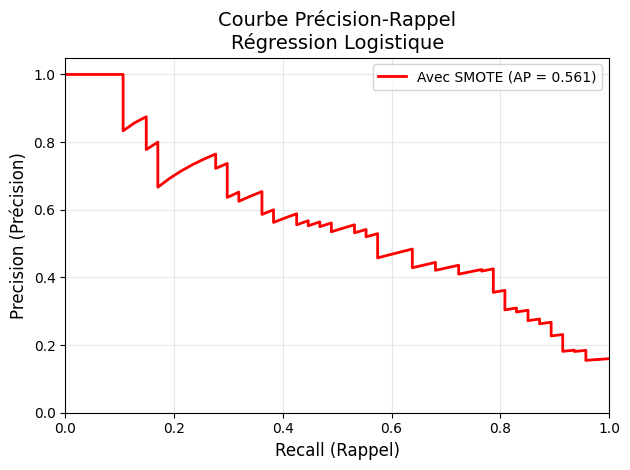

In [150]:
# Calcul de la Courbe Preciion-Rappel
precision_logreg_avec, recall_logreg_avec, _ = precision_recall_curve(y_test, y_proba_logreg_smote)

ap_logreg_avec = average_precision_score(y_test, y_proba_logreg_smote)


print(f"\nAverage Precision (AP) - Régression Logistique:")
print(f"  AVEC SMOTE: {ap_logreg_avec:.4f}")


print("\n VISUALISATION ")

# Baseline (proportion de la classe minoritaire)
no_skill = (y_test == 1).sum() / len(y_test)
plt.figure
plt.plot(recall_logreg_avec, precision_logreg_avec, color='red', lw=2,
         label=f'Avec SMOTE (AP = {ap_logreg_avec:.3f})')
plt.xlabel('Recall (Rappel)', fontsize=12)
plt.ylabel('Precision (Précision)', fontsize=12)
plt.title('Courbe Précision-Rappel\nRégression Logistique', 
              fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

In [151]:
# Rappel du contexte: le RH veut minimiser les salariés considérés comme ne quitteront pas alors qu'ils sont réellement partis
# soit minimiser les faux négatifs (qui diminuent petit à petit en améliorant nos modèles) = augmenter le recall

In [152]:
### GridSerch CV sur forêt aléatoire avec SMOTE et K-Fold ###

In [153]:
# Pipeline avec SMOTE
pipeline_grid = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [154]:
# Grille de paramètres
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 15, 20],
    'classifier__min_samples_split': [10, 20],
}

In [155]:
# K-Fold stratifié (garde les proportions des classes)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [156]:
# GridSearchCV avec cross-validation
grid_search = GridSearchCV(
    pipeline_grid,
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='roc_auc',       # Métrique d'optimisation
    n_jobs=-1,
    verbose=1,
    return_train_score=True  # Pour analyser l'overfitting
)

In [157]:
grid_search.fit(X_final_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score CV    : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Meilleurs paramètres : {'classifier__max_depth': 15, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 50}
Meilleur score CV    : 0.8131


In [158]:
# Résultats détaillés
cv_results_grid = pd.DataFrame(grid_search.cv_results_)

print("\n TOP 5 COMBINAISONS :")
top_5 = cv_results_grid.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'mean_train_score']
]
print(top_5.to_string(index=False))


 TOP 5 COMBINAISONS :
                                                                                             params  mean_test_score  std_test_score  mean_train_score
 {'classifier__max_depth': 15, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 50}         0.813111        0.062315          0.988166
 {'classifier__max_depth': 20, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 50}         0.813035        0.064308          0.988173
{'classifier__max_depth': 15, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 100}         0.810444        0.063301          0.989926
 {'classifier__max_depth': 20, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}         0.810340        0.053314          0.998961
{'classifier__max_depth': 20, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 100}         0.809726        0.064818          0.990078


In [159]:
# Évaluer sur le test set final
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_final_test)
y_proba_final = best_model.predict_proba(X_final_test)[:, 1]


acc_final = accuracy_score(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_proba_final)

print(f"\n PERFORMANCE SUR TEST SET FINAL :")
print(f"   Accuracy : {acc_final:.4f}")
print(f"   ROC-AUC  : {auc_final:.4f}")

print(f"\n COMPARAISON CV vs TEST :")
print(f"   CV ROC-AUC  : {grid_search.best_score_:.4f}")
print(f"   Test ROC-AUC: {auc_final:.4f}")
print(f"   Différence  : {abs(grid_search.best_score_ - auc_final):.4f}")

# Classification Report
print("\n CLASSIFICATION REPORT (Test Set)")
print(classification_report(y_test, y_pred_final,
                          target_names=['Non quitté (0)', 'A Quitté (1)']))


 PERFORMANCE SUR TEST SET FINAL :
   Accuracy : 0.8503
   ROC-AUC  : 0.7927

 COMPARAISON CV vs TEST :
   CV ROC-AUC  : 0.8131
   Test ROC-AUC: 0.7927
   Différence  : 0.0204

 CLASSIFICATION REPORT (Test Set)
                precision    recall  f1-score   support

Non quitté (0)       0.87      0.97      0.92       247
  A Quitté (1)       0.59      0.21      0.31        47

      accuracy                           0.85       294
     macro avg       0.73      0.59      0.61       294
  weighted avg       0.82      0.85      0.82       294



In [160]:
# Matrice de confusion - RF
cm_rf = confusion_matrix(y_test, y_pred_final)
cm_rf_df = pd.DataFrame(cm_logreg, 
                     index=['Réel: Non (0)', 'Réel: Oui (1)'],
                     columns=['Prédit: Non (0)', 'Prédit: Oui (1)'])
print(cm_rf_df)


               Prédit: Non (0)  Prédit: Oui (1)
Réel: Non (0)              203               44
Réel: Oui (1)               15               32


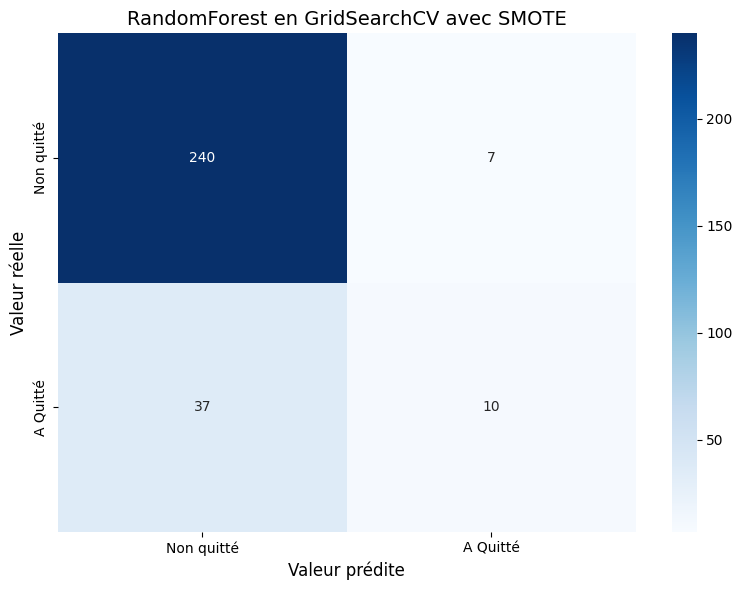

In [161]:
#traçage de la Courbe
cm_rf= confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non quitté', 'A Quitté'],
            yticklabels=['Non quitté', 'A Quitté'])
plt.title('RandomForest en GridSearchCV avec SMOTE', fontsize=14)
plt.ylabel('Valeur réelle', fontsize=12)
plt.xlabel('Valeur prédite', fontsize=12)
plt.tight_layout()
plt.show()

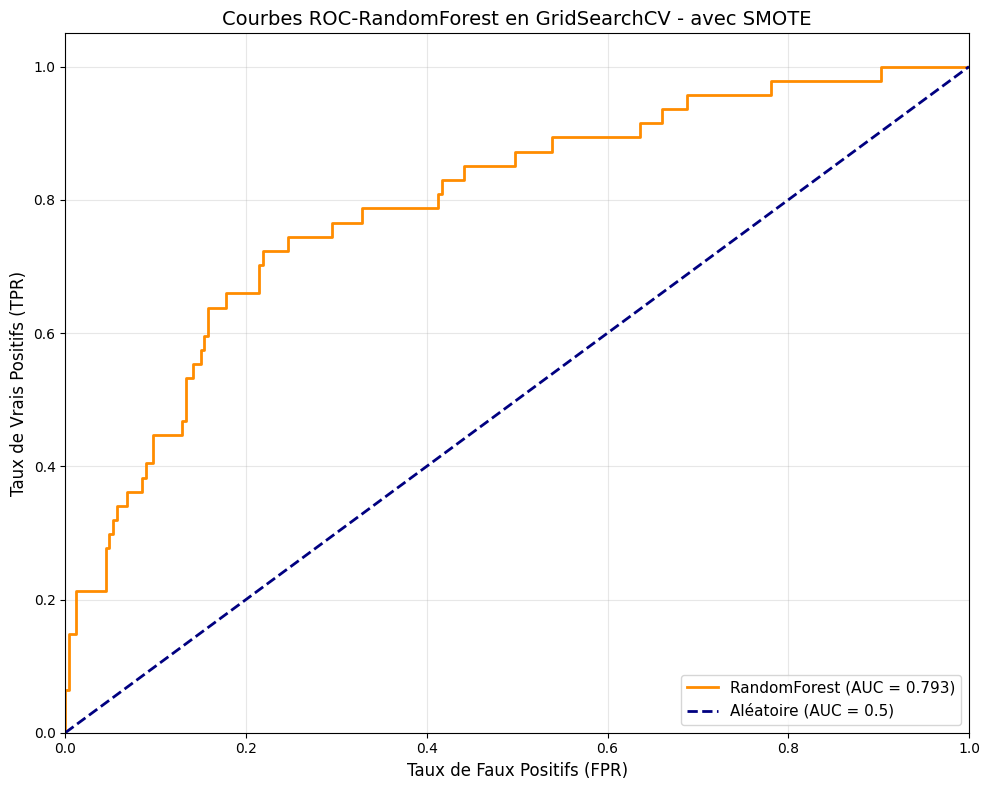

In [162]:
# Calcul de la courbe ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_final)

roc_auc_rf = auc(fpr_rf, tpr_rf)


# Traçage
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2,
         label=f'RandomForest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Aléatoire (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC-RandomForest en GridSearchCV - avec SMOTE', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Average Precision (AP) - Régression Logistique:
  AVEC SMOTE: 0.4853

 VISUALISATION 


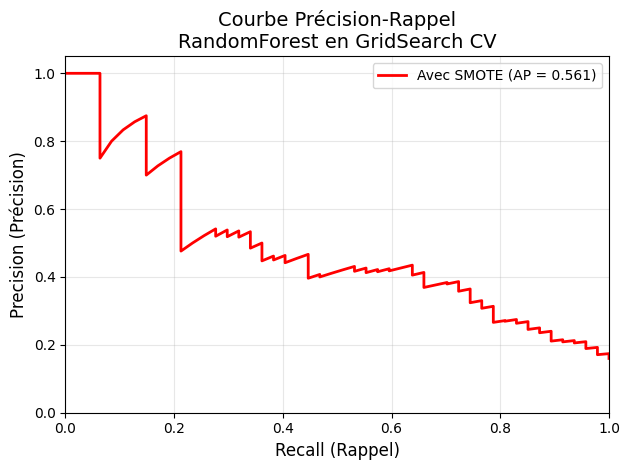

In [163]:
# Calcul de la Courbe Preciion-Rappel
precision_rf_avec, recall_rf_avec, _ = precision_recall_curve(y_test, y_proba_final)

ap_rf_avec = average_precision_score(y_test, y_proba_final)


print(f"\nAverage Precision (AP) - Régression Logistique:")
print(f"  AVEC SMOTE: {ap_rf_avec:.4f}")


print("\n VISUALISATION ")

# Baseline (proportion de la classe minoritaire)
no_skill = (y_test == 1).sum() / len(y_test)
plt.figure
plt.plot(recall_rf_avec, precision_rf_avec, color='red', lw=2,
         label=f'Avec SMOTE (AP = {ap_logreg_avec:.3f})')
plt.xlabel('Recall (Rappel)', fontsize=12)
plt.ylabel('Precision (Précision)', fontsize=12)
plt.title('Courbe Précision-Rappel\nRandomForest en GridSearch CV', 
              fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

In [164]:
# GridSerch CV sur Regression Logistique avec SMOTE et K-Fold (notre meilleur modèle)

In [165]:
# Pipeline avec SMOTE + Logistic Regression
pipeline_logreg = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])

In [166]:
# Paramètres à tester pour la Régression Logistique
param_grid_logreg_simple = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],  # L2 fonctionne avec tous les solvers
    'classifier__solver': ['liblinear', 'lbfgs', 'saga'],
    'classifier__max_iter': [1000, 2000]
}
print(f"Nombre de combinaisons à tester : {
    len(param_grid_logreg_simple['classifier__C']) * 
    len(param_grid_logreg_simple['classifier__penalty']) * 
    len(param_grid_logreg_simple['classifier__solver']) * 
    len(param_grid_logreg_simple['classifier__max_iter'])
}")

print("\nParamètres testés :")
for param, values in param_grid_logreg_simple.items():
    print(f"  {param:<30} : {values}")

Nombre de combinaisons à tester : 30

Paramètres testés :
  classifier__C                  : [0.01, 0.1, 1, 10, 100]
  classifier__penalty            : ['l2']
  classifier__solver             : ['liblinear', 'lbfgs', 'saga']
  classifier__max_iter           : [1000, 2000]


In [167]:
# K-Fold stratifié
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_logreg = GridSearchCV(
    pipeline_logreg,
    param_grid_logreg_simple,
    cv=skf,
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [168]:
# Entraînement
grid_logreg.fit(X_final_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__max_iter': [1000, 2000], 'classifier__penalty': ['l2'], 'classifier__solver': ['liblinear', 'lbfgs', ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,sampling_strategy,'auto'


In [169]:
print(f"\nMeilleur score (ROC-AUC CV) : {grid_logreg.best_score_:.4f}")
print(f"\nMeilleurs paramètres :")
for param, value in grid_logreg.best_params_.items():
    print(f"  {param:<30} : {value}")


Meilleur score (ROC-AUC CV) : 0.8406

Meilleurs paramètres :
  classifier__C                  : 0.1
  classifier__max_iter           : 1000
  classifier__penalty            : l2
  classifier__solver             : lbfgs


In [170]:
# Convertion en DataFrame
cv_results_df = pd.DataFrame(grid_logreg.cv_results_)

# Top 10 combinaisons
print("\nTop 10 meilleures combinaisons :")
top_10 = cv_results_df.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print(top_10.to_string(index=False))


Top 10 meilleures combinaisons :
                                                                                                              params  mean_test_score  std_test_score  rank_test_score
    {'classifier__C': 0.1, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}         0.840625        0.023795                1
    {'classifier__C': 0.1, 'classifier__max_iter': 2000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}         0.840625        0.023795                1
     {'classifier__C': 0.1, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}         0.840491        0.023783                3
     {'classifier__C': 0.1, 'classifier__max_iter': 2000, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}         0.840491        0.023783                3
       {'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}         0.8378

In [171]:
# test set
# Utiliser le meilleur modèle
best_logreg = grid_logreg.best_estimator_

# Prédictions
y_pred_logreg = best_logreg.predict(X_final_test)
y_proba_logreg = best_logreg.predict_proba(X_final_test)[:, 1]

# Métriques
acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_proba_logreg)

print(f"\nPerformance sur TEST SET :")
print(f"  Accuracy : {acc_logreg:.4f}")
print(f"  ROC-AUC  : {auc_logreg:.4f}")

print(f"\nComparaison CV vs TEST :")
print(f"  ROC-AUC (CV)   : {grid_logreg.best_score_:.4f}")
print(f"  ROC-AUC (Test) : {auc_logreg:.4f}")
print(f"  Différence     : {abs(grid_logreg.best_score_ - auc_logreg):.4f}")

if abs(grid_logreg.best_score_ - auc_logreg) < 0.05:
    print("  Le modèle généralise bien")
else:
    print("   Différence notable entre CV et Test")

# Classification Report
print("\n CLASSIFICATION REPORT (Test Set)")
print(classification_report(y_test, y_pred_logreg,
                          target_names=['Non quitté (0)', 'A Quitté (1)']))


Performance sur TEST SET :
  Accuracy : 0.8163
  ROC-AUC  : 0.8181

Comparaison CV vs TEST :
  ROC-AUC (CV)   : 0.8406
  ROC-AUC (Test) : 0.8181
  Différence     : 0.0226
  Le modèle généralise bien

 CLASSIFICATION REPORT (Test Set)
                precision    recall  f1-score   support

Non quitté (0)       0.94      0.83      0.88       247
  A Quitté (1)       0.45      0.74      0.56        47

      accuracy                           0.82       294
     macro avg       0.70      0.79      0.72       294
  weighted avg       0.87      0.82      0.83       294



In [172]:
# Matrice de confusion - Régression Logistique avec SMOTE
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_logreg_df = pd.DataFrame(cm_logreg, 
                     index=['Réel: Non (0)', 'Réel: Oui (1)'],
                     columns=['Prédit: Non (0)', 'Prédit: Oui (1)'])
print(cm_logreg_df)


               Prédit: Non (0)  Prédit: Oui (1)
Réel: Non (0)              205               42
Réel: Oui (1)               12               35


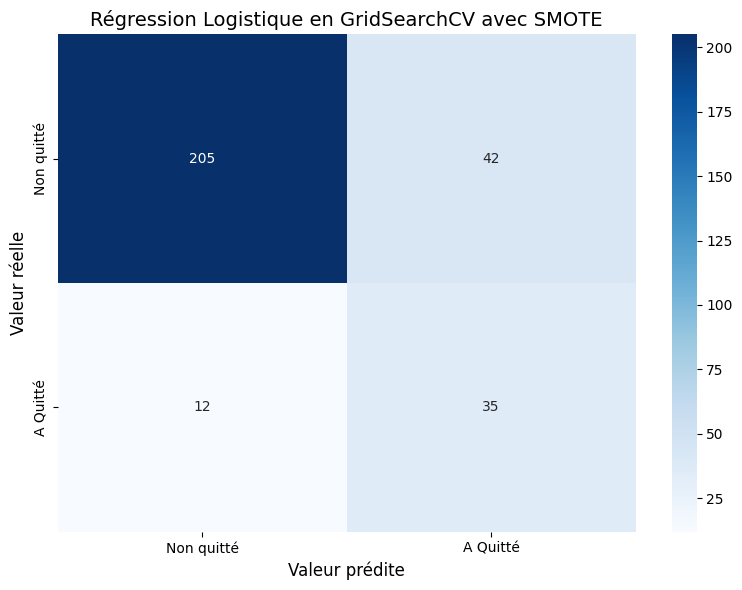

In [173]:
#traçage de la Courbe
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non quitté', 'A Quitté'],
            yticklabels=['Non quitté', 'A Quitté'])
plt.title('Régression Logistique en GridSearchCV avec SMOTE', fontsize=14)
plt.ylabel('Valeur réelle', fontsize=12)
plt.xlabel('Valeur prédite', fontsize=12)
plt.tight_layout()
plt.show()

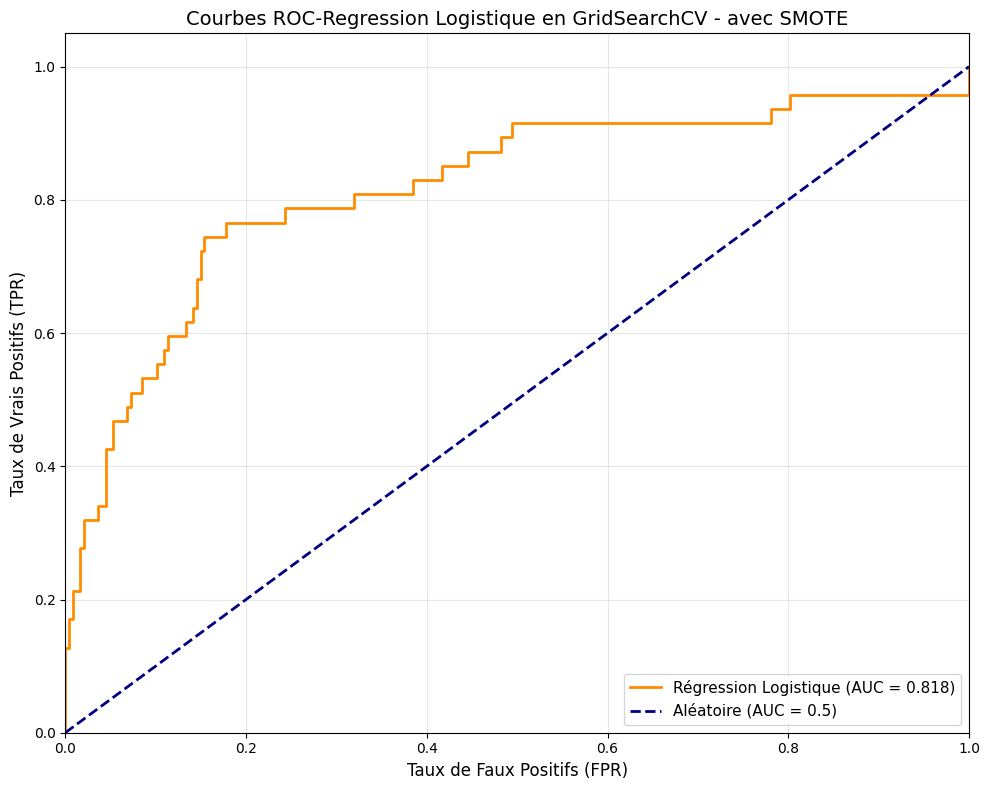

In [174]:
# Calcul de la courbe ROC
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)

roc_auc_logreg = auc(fpr_logreg, tpr_logreg)


# Traçage
plt.figure(figsize=(10, 8))
plt.plot(fpr_logreg, tpr_logreg, color='darkorange', lw=2,
         label=f'Régression Logistique (AUC = {roc_auc_logreg:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Aléatoire (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC-Regression Logistique en GridSearchCV - avec SMOTE', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Average Precision (AP) - Régression Logistique:
  AVEC SMOTE: 0.5796

 VISUALISATION 


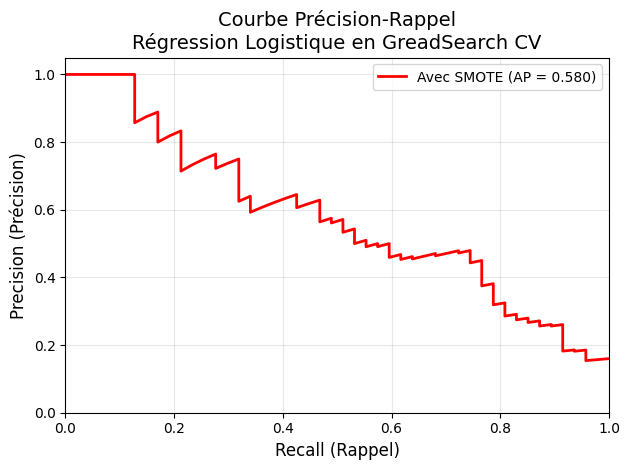

In [175]:
# Calcul de la Courbe Preciion-Rappel
precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_proba_logreg)

ap_logreg = average_precision_score(y_test, y_proba_logreg)


print(f"\nAverage Precision (AP) - Régression Logistique:")
print(f"  AVEC SMOTE: {ap_logreg:.4f}")


print("\n VISUALISATION ")

# Baseline (proportion de la classe minoritaire)
no_skill = (y_test == 1).sum() / len(y_test)
plt.figure
plt.plot(recall_logreg, precision_logreg, color='red', lw=2,
         label=f'Avec SMOTE (AP = {ap_logreg:.3f})')
plt.xlabel('Recall (Rappel)', fontsize=12)
plt.ylabel('Precision (Précision)', fontsize=12)
plt.title('Courbe Précision-Rappel\nRégression Logistique en GreadSearch CV', 
              fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

In [176]:
# PERMUTATION IMPORTANCE - RÉGRESSION LOGISTIQUE

In [177]:
# Meilleur modèle du GridSearchCV
best_logreg = grid_logreg.best_estimator_

# Si c'est un Pipeline, extraire le modèle
if hasattr(best_logreg, 'named_steps'):
    logreg_model = best_logreg.named_steps['classifier']
    print( "Modèle extrait du Pipeline")
else:
    logreg_model = best_logreg

print(f"Type du modèle : {type(logreg_model)}")

Modèle extrait du Pipeline
Type du modèle : <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [178]:
print("\n Calcul de la Permutation Importance...")


# Calculer sur le TEST SET
perm_importance = permutation_importance(
    best_logreg,              # Le pipeline complet (avec SMOTE)
    X_final_test,             # Calculer sur le TEST SET
    y_test,
    n_repeats=10,             # Nombre de permutations par feature
    random_state=42,
    scoring='roc_auc',        # Métrique à optimiser
    n_jobs=-1                 # Parallélisation
)


 Calcul de la Permutation Importance...


In [179]:
# Récupére les noms des features
feature_names = X_final_train.columns

# Crée un DataFrame
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

# Afficher le top 10
print("\n TOP 10 FEATURES - PERMUTATION IMPORTANCE")
print(perm_importance_df.head(20).to_string(index=False))



 TOP 10 FEATURES - PERMUTATION IMPORTANCE
                             Feature  Importance_Mean  Importance_Std
               heure_supplementaires         0.098372        0.012832
               frequence_deplacement         0.028047        0.009462
      nombre_experiences_precedentes         0.026238        0.007324
satisfaction_employee_nature_travail         0.024748        0.005664
            annees_dans_l_entreprise         0.018873        0.015753
               nb_formations_suivies         0.018710        0.004497
 annees_depuis_la_derniere_promotion         0.018150        0.005596
          note_evaluation_precedente         0.015445        0.007284
            nombre_participation_pee         0.015419        0.006885
 satisfaction_employee_environnement         0.015410        0.007665
                               genre         0.013360        0.004626
           statut_marital_Divorcé(e)         0.012835        0.010150
                                 age         0.

In [180]:
print(f"Importance max  : {perm_importance_df['Importance_Mean'].max():.4f}")
print(f"Importance min  : {perm_importance_df['Importance_Mean'].min():.4f}")
print(f"Importance moy  : {perm_importance_df['Importance_Mean'].mean():.4f}")


Importance max  : 0.0984
Importance min  : -0.0021
Importance moy  : 0.0099


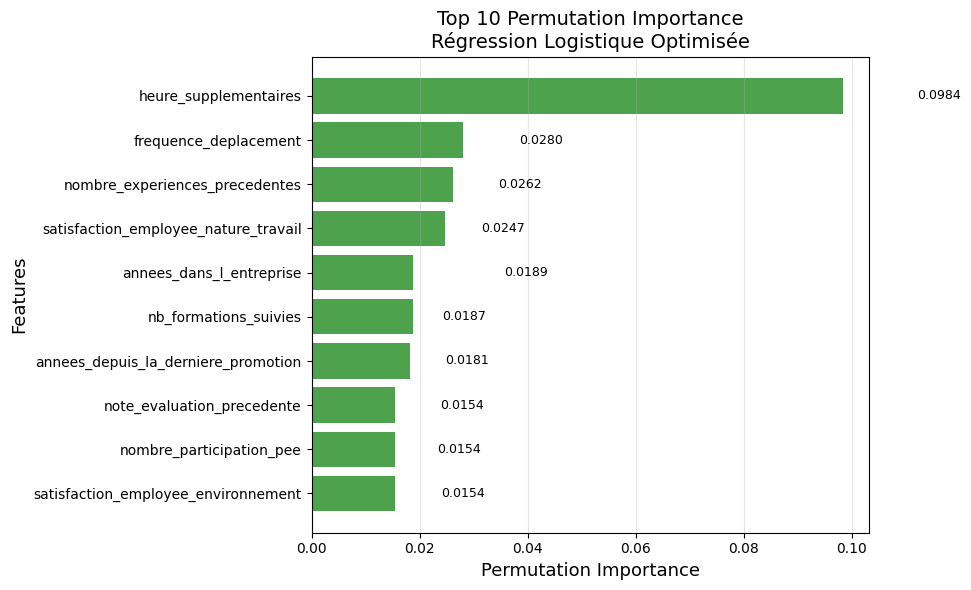

In [181]:
# VISUALISATION 
plt.figure(figsize=(10, 6))

top_10 = perm_importance_df.head(10)

plt.barh(top_10['Feature'], top_10['Importance_Mean'], 
                  color='forestgreen', alpha=0.8, capsize=5)
plt.xlabel('Permutation Importance', fontsize=13)
plt.ylabel('Features', fontsize=13)
plt.title('Top 10 Permutation Importance\nRégression Logistique Optimisée', 
          fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for i, (feature, importance, std) in enumerate(zip(top_10['Feature'], 
                                                     top_10['Importance_Mean'], 
                                                     top_10['Importance_Std'])):
    plt.text(importance + std + 0.001, i, f'{importance:.4f}', 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [182]:
# ÉTAPE 1 : PRÉPARATION DES DONNÉES ET MODÈLE

print(" PRÉPARATION DES DONNÉES POUR SHAP")


# Extraire le modèle du pipeline
if hasattr(best_logreg, 'named_steps'):
    logreg_model = best_logreg.named_steps['classifier']
    print("✓ Modèle LogisticRegression extrait du Pipeline")
else:
    logreg_model = best_logreg
    print("✓ Modèle utilisé directement")

# Appliquer SMOTE sur les données d'entraînement
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_final_train, y_train)
X_train_smote_df = pd.DataFrame(X_train_smote, columns=X_final_train.columns)

print(f"✓ SMOTE appliqué : {X_train_smote_df.shape}")

 PRÉPARATION DES DONNÉES POUR SHAP
✓ Modèle LogisticRegression extrait du Pipeline
✓ SMOTE appliqué : (1972, 36)


In [183]:
# ÉTAPE 2 : CRÉER LE LINEAR EXPLAINER ET CALCULER LES SHAP VALUES


print(" CALCUL DES SHAP VALUES")


# Créer l'explainer
linear_explainer = shap.LinearExplainer(logreg_model, X_train_smote_df)
print(" LinearExplainer créé")

# Calculer les SHAP values sur tout le test set
shap_values_linear = linear_explainer.shap_values(X_final_test)

# Extraire la classe 1 (départ)
if isinstance(shap_values_linear, (list, tuple)):
    shap_values_class1 = shap_values_linear[1]
else:
    shap_values_class1 = shap_values_linear

print(f"✓ SHAP values calculées : {shap_values_class1.shape}")
print(f"✓ X_final_test shape    : {X_final_test.shape}")
print(f"✓ Dimensions compatibles : {shap_values_class1.shape == (X_final_test.shape[0], X_final_test.shape[1])}")

 CALCUL DES SHAP VALUES
 LinearExplainer créé
✓ SHAP values calculées : (294, 36)
✓ X_final_test shape    : (294, 36)
✓ Dimensions compatibles : True


 GRAPHIQUE 1 : BEESWARM PLOT


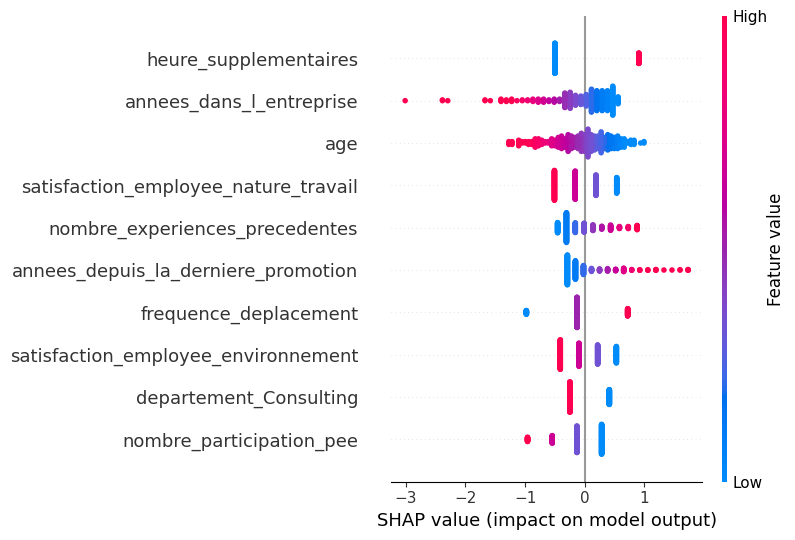

✓ Beeswarm plot généré avec 294 observations


In [184]:
# GRAPHIQUE 1 : BEESWARM PLOT


print(" GRAPHIQUE 1 : BEESWARM PLOT")

shap.summary_plot(
    shap_values_class1,
    X_final_test,
    max_display=10
)

print(f"✓ Beeswarm plot généré avec {X_final_test.shape[0]} observations")

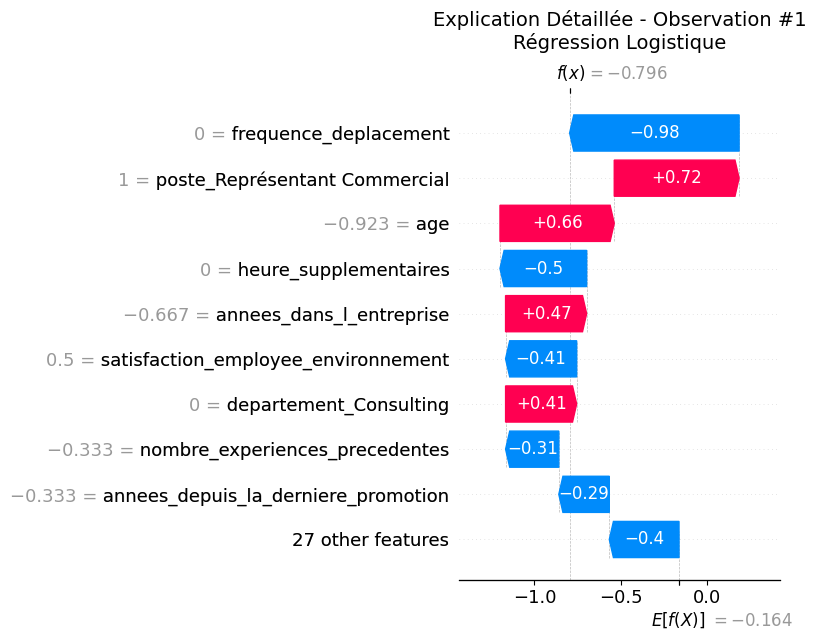

In [185]:
# GRAPHIQUE 4 : WATERFALL PLOT (EXPLICATION INDIVIDUELLE)


# Choisir une observation intéressante
observation_index = 0

# Base value
if isinstance(linear_explainer.expected_value, (list, np.ndarray)):
    base_value = linear_explainer.expected_value[1]
else:
    base_value = linear_explainer.expected_value

# Créer l'objet Explanation
shap_exp_single = shap.Explanation(
    values=shap_values_class1[observation_index],
    base_values=base_value,
    data=X_final_test.iloc[observation_index].values,
    feature_names=X_final_test.columns.tolist()
)

# Générer le waterfall plot
plt.figure(figsize=(12, 10))
shap.waterfall_plot(shap_exp_single, max_display=10, show=False)
plt.title(f'Explication Détaillée - Observation #{observation_index + 1}\nRégression Logistique', 
          fontsize=14, pad=10)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

# Afficher les détails
y_real = y_test.iloc[observation_index]
y_pred = best_logreg.predict(X_final_test.iloc[[observation_index]])[0]
y_proba = best_logreg.predict_proba(X_final_test.iloc[[observation_index]])[0, 1]



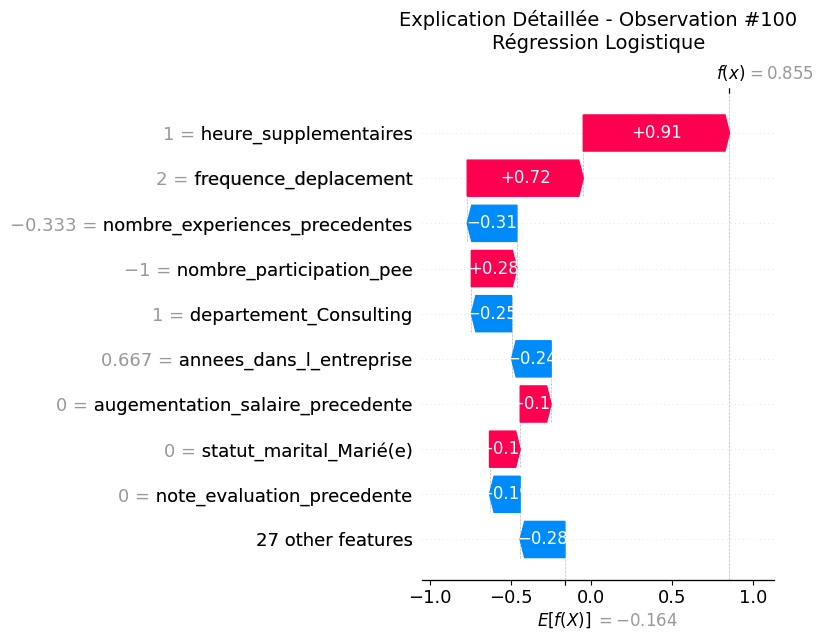

In [186]:
# WATERFALL PLOT (EXPLICATION INDIVIDUELLE)


# Choisir une observation intéressante
observation_index = 99

# Base value
if isinstance(linear_explainer.expected_value, (list, np.ndarray)):
    base_value = linear_explainer.expected_value[1]
else:
    base_value = linear_explainer.expected_value

# Créer l'objet Explanation
shap_exp_single = shap.Explanation(
    values=shap_values_class1[observation_index],
    base_values=base_value,
    data=X_final_test.iloc[observation_index].values,
    feature_names=X_final_test.columns.tolist()
)

# Générer le waterfall plot
plt.figure(figsize=(12, 10))
shap.waterfall_plot(shap_exp_single, max_display=10, show=False)
plt.title(f'Explication Détaillée - Observation #{observation_index + 1}\nRégression Logistique', 
          fontsize=14, pad=10)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

# Afficher les détails
y_real = y_test.iloc[observation_index]
y_pred = best_logreg.predict(X_final_test.iloc[[observation_index]])[0]
y_proba = best_logreg.predict_proba(X_final_test.iloc[[observation_index]])[0, 1]


In [ ]:
import joblib
# Sauvegarder le modèle
joblib.dump(pipeline_logreg , 'model.joblib')
print("Modèle sauvegardé sous 'model.joblib'")
